In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sktime.forecasting.tbats import TBATS
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout

warnings.filterwarnings('ignore', category=FutureWarning)

tf.random.set_seed(42)
np.random.seed(42)

/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df_count = sales[['account_id', 'sales_channel_id']].value_counts()
df_count = pd.DataFrame(df_count).reset_index()

In [4]:
EPOCHS = 1000
BATCH_SIZE = 32
VALID_SPLIT = 0.1

In [5]:
ALL_SALES_CHANNELS = True
LOOKBACK = 3
CRIT_VALUE = 0.25
COVERAGE = 0.2
SEASONAL_PERIODS=[24, 24*7]
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [7]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [8]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

Processing account_id: 74abffac-6542-4eff-8eae-cc85463a5d02, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 2556.9341 - val_loss: 2884.2505
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 2553.2805 - val_loss: 2877.7107
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2542.8323 - val_loss: 2863.1685
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2524.4219 - val_loss: 2840.7578
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2497.9971 - val_loss: 2810.5237
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2463.7346 - val_loss: 2772.7788
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 2423.1216 - val_loss: 2727.9976
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2374.6470 - val_loss: 2675.4856
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2319.2634 - val_loss: 2616.4172
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 2256.4119 - val_loss: 2550.8069
Epoch 

,feature,coef
0,tbats,0.090678
1,gb,1.096442
2,lstm,-0.096076


train RMSE: 894.629
train MAE:  618.833
test RMSE: 868.481
test MAE:  657.411


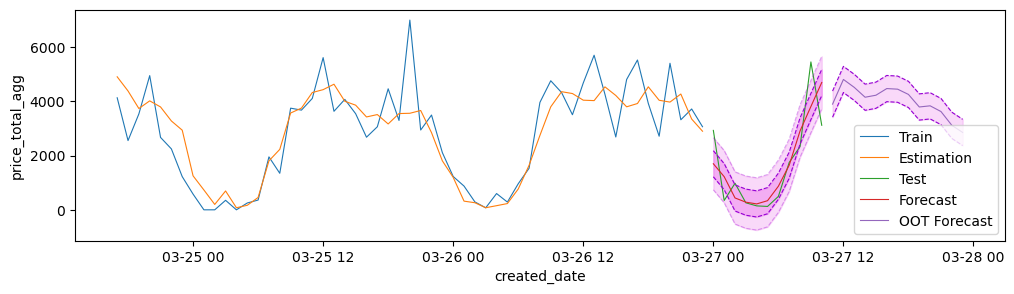

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 17.1751 - val_loss: 17.1400
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 13.9709 - val_loss: 11.7869
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6.9359 - val_loss: 4.9569
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 5.0160 - val_loss: 4.7875
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 4.8896 - val_loss: 4.7687
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 4.7738 - val_loss: 4.5733
Epoch 7/1000
60/60 - 0s - 5ms/step - loss: 4.8957 - val_loss: 4.6698
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 4.6864 - val_loss: 4.5821
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4.7804 - val_loss: 4.5261
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 4.6287 - val_loss: 4.5396
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 4.6487 - val_loss: 4.4956
Epoch 12/1000
60/60 - 0s - 4ms/step - loss: 4.5597 - val_loss: 4.4471
Epoch 13/100

,feature,coef
0,tbats,-0.032570
1,gb,1.198905
2,lstm,-0.085172


train RMSE: 2.370
train MAE:  1.232
test RMSE: 4.883
test MAE:  3.309


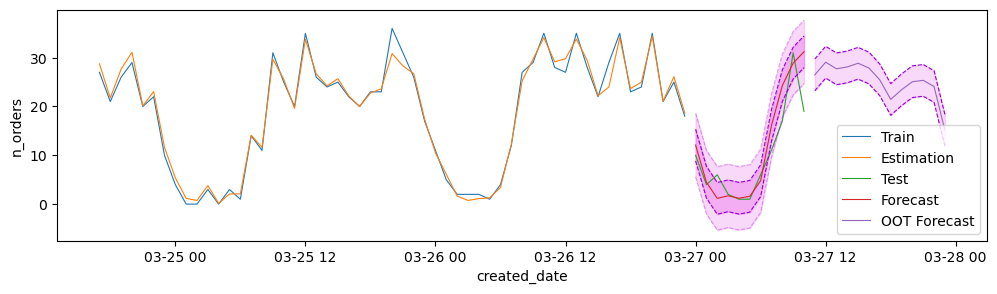

Processing account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 4503.7793 - val_loss: 6033.3672
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 4502.3857 - val_loss: 6029.4561
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 4497.6826 - val_loss: 6019.1997
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 4487.7598 - val_loss: 6001.4976
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 4471.9053 - val_loss: 5976.5396
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 4450.9614 - val_loss: 5945.5381
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 4425.7983 - val_loss: 5909.0488
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 4395.7783 - val_loss: 5867.2085
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4361.1831 - val_loss: 5820.3374
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 4324.7329 - val_loss: 5768.7788
Epoch 

,feature,coef
0,tbats,0.518307
1,gb,0.554567
2,lstm,0.101327


train RMSE: 4185.582
train MAE:  2814.701
test RMSE: 1753.470
test MAE:  1547.994


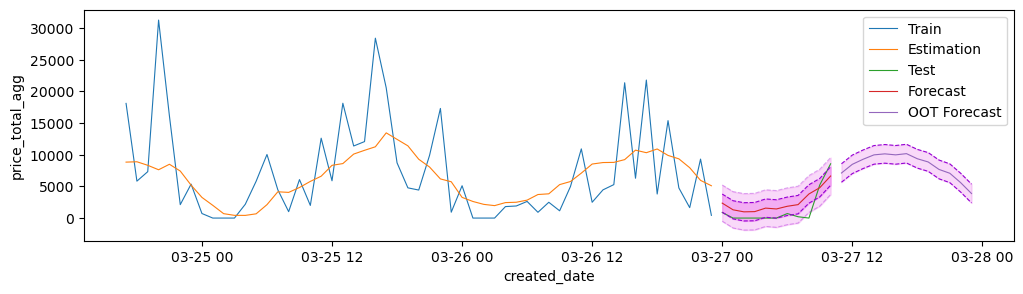

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 3s - 44ms/step - loss: 3.9353 - val_loss: 3.0495
Epoch 2/1000
60/60 - 0s - 5ms/step - loss: 2.7474 - val_loss: 1.8295
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 2.0907 - val_loss: 1.8661
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 2.0773 - val_loss: 1.8627
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 2.0651 - val_loss: 1.8511
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Epoch 1/1000
61/61 - 2s - 36ms/step - loss: 3.8967 - val_loss: 2.9757
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 2.6952 - val_loss: 1.8139
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 2.0885 - val_loss: 1.8417
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 2.0645 - val_loss: 1.8439
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 2.0825 - val_loss: 1.8260
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/

,feature,coef
0,tbats,-0.028898
1,gb,1.359880
2,lstm,-0.196096


train RMSE: 2.616
train MAE:  1.759
test RMSE: 1.125
test MAE:  0.726


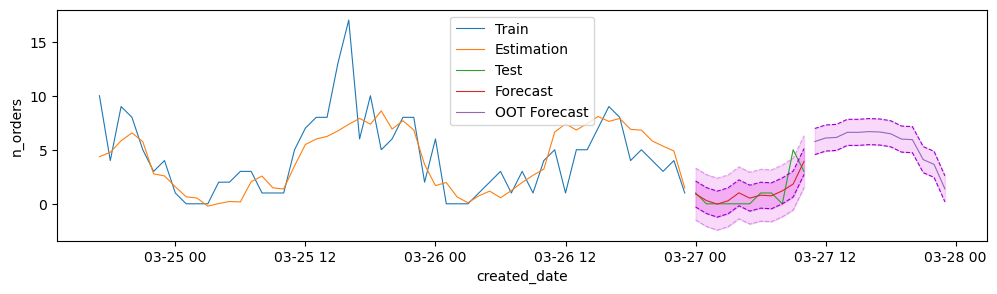

Processing account_id: c0cc925b-66c1-4b1c-b609-1bddc82ef4a4, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 23ms/step - loss: 31.8046 - val_loss: 0.0050
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 31.7881 - val_loss: 0.0036
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 31.7819 - val_loss: 2.9738e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 31.7778 - val_loss: 0.0010
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 31.7733 - val_loss: 2.2212e-04
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 31.7698 - val_loss: 3.4474e-04
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 31.7673 - val_loss: 5.0330e-04
Epoch 8/1000
60/60 - 0s - 5ms/step - loss: 31.7639 - val_loss: 8.9718e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoch 1/1000
61/61 - 2s - 29ms/step - loss: 31.6362 - val_loss: 0.0010
Epoch 2/1000
61/61 - 0s - 3ms

,feature,coef
0,tbats,0.756720
1,gb,0.000000
2,lstm,536.231518


train RMSE: 83.001
train MAE:  41.114
test RMSE: 21.229
test MAE:  19.890


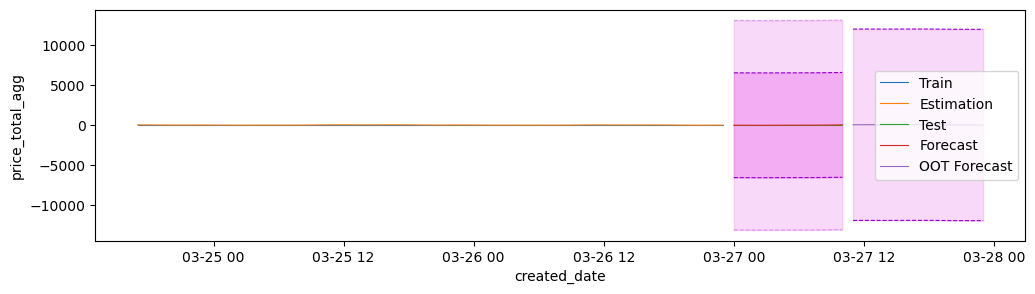

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 23ms/step - loss: 0.2719 - val_loss: 0.0071
Epoch 2/1000
60/60 - 0s - 4ms/step - loss: 0.2593 - val_loss: 8.7149e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.2542 - val_loss: 0.0055
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 0.2487 - val_loss: 0.0011
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 0.2438 - val_loss: 4.6163e-04
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 0.2405 - val_loss: 8.6652e-04
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.2390 - val_loss: 7.6809e-05
Epoch 8/1000
60/60 - 0s - 4ms/step - loss: 0.2368 - val_loss: 0.0012
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.2352 - val_loss: 6.4643e-04
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 0.2336 - val_loss: 2.2347e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Epoch 1/1000
61/61 - 2s - 27ms/step - loss: 0.2762 - va

,feature,coef
0,tbats,0.695536
1,gb,0.000000
2,lstm,4.432681


train RMSE: 0.462
train MAE:  0.279
test RMSE: 0.085
test MAE:  0.078


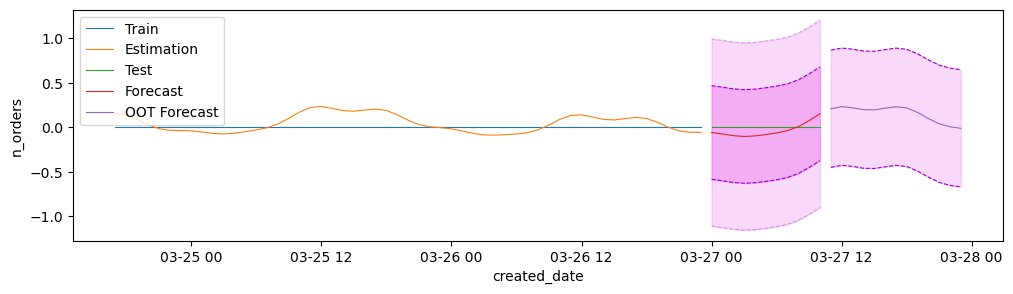

Processing account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 899.5830 - val_loss: 753.2570
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 897.7230 - val_loss: 751.0799
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 891.9430 - val_loss: 745.4725
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 880.9064 - val_loss: 735.9019
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 864.3705 - val_loss: 722.5222
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 843.0711 - val_loss: 705.4672
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 816.6628 - val_loss: 685.8718
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 789.3411 - val_loss: 664.1545
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 757.4689 - val_loss: 643.7892
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 726.4841 - val_loss: 624.0308
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.381014
1,gb,0.988463
2,lstm,-0.201254


train RMSE: 663.661
train MAE:  459.216
test RMSE: 612.367
test MAE:  413.357


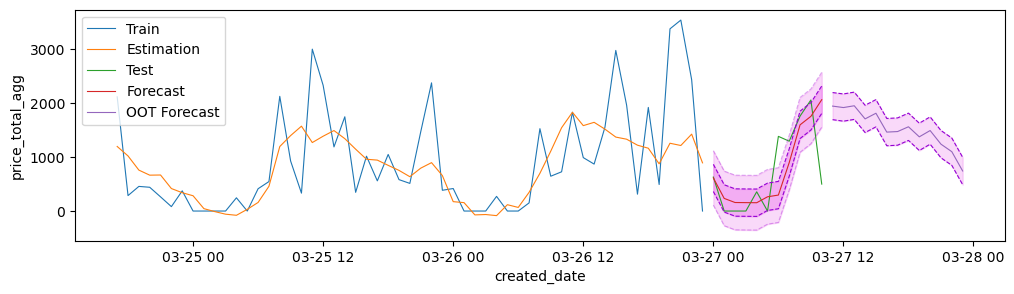

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 3.0817 - val_loss: 2.0891
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.9670 - val_loss: 1.5953
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.8092 - val_loss: 1.5810
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.7786 - val_loss: 1.5652
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.7190 - val_loss: 1.5638
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.7242 - val_loss: 1.5668
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.7078 - val_loss: 1.5770
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.6883 - val_loss: 1.5792
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 2.9821 - val_loss: 1.9919
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 1.9323 - val_loss: 1.6313
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 1.7704 - val_loss: 1.6082
Epoch 4/10

,feature,coef
0,tbats,0.249398
1,gb,1.057573
2,lstm,-0.154446


train RMSE: 2.016
train MAE:  1.433
test RMSE: 2.422
test MAE:  1.651


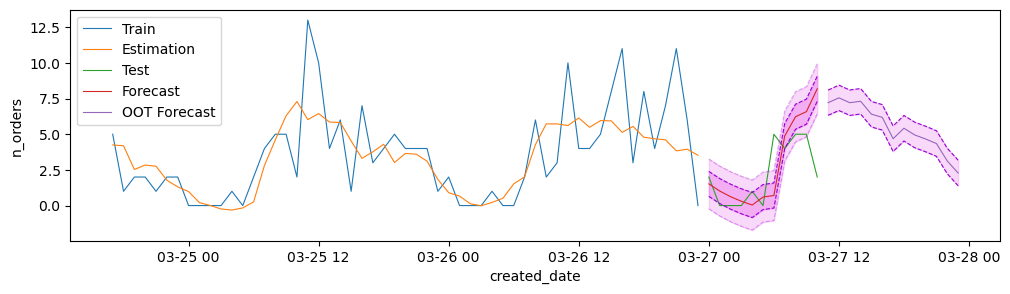

Processing account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 6656.6948 - val_loss: 8844.0996
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 6654.2588 - val_loss: 8838.2705
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 6646.4966 - val_loss: 8824.2119
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6631.7554 - val_loss: 8801.9893
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 6609.7344 - val_loss: 8772.0732
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 6581.8711 - val_loss: 8735.3223
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 6547.5449 - val_loss: 8691.9316
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 6508.5522 - val_loss: 8640.9033
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 6459.5581 - val_loss: 8582.3574
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 6404.7559 - val_loss: 8515.7012
Epoch 

,feature,coef
0,tbats,-0.203411
1,gb,1.573625
2,lstm,-0.185219


train RMSE: 2101.361
train MAE:  1255.434
test RMSE: 1951.992
test MAE:  1605.120


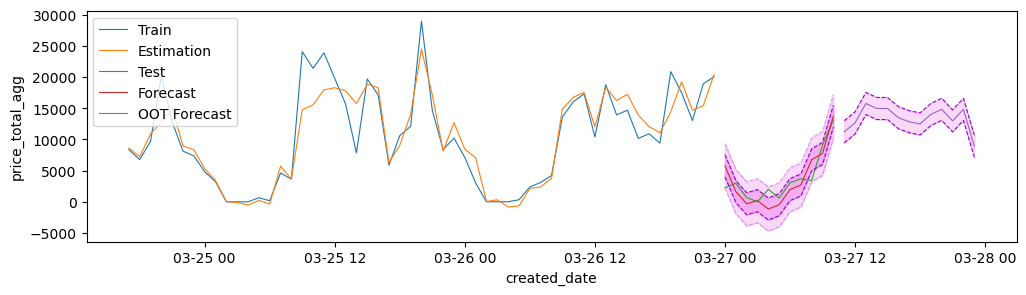

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 14.7349 - val_loss: 16.8808
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 11.8841 - val_loss: 10.6638
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6.5930 - val_loss: 5.5984
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 5.2991 - val_loss: 5.5227
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 5.2122 - val_loss: 5.4607
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 5.1317 - val_loss: 5.4716
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 5.0848 - val_loss: 5.4325
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 5.0185 - val_loss: 5.3928
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 5.0253 - val_loss: 5.3681
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 5.1004 - val_loss: 5.3480
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 4.9987 - val_loss: 5.3588
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4.9436 - val_loss: 5.3313
Epoch 13/100

,feature,coef
0,tbats,-0.129181
1,gb,1.291769
2,lstm,-0.065138


train RMSE: 2.933
train MAE:  1.596
test RMSE: 4.467
test MAE:  3.556


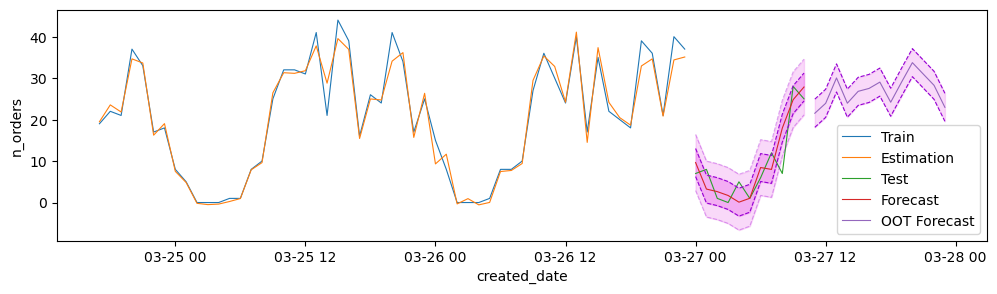

Processing account_id: 92f116fe-5818-41db-9eb5-87445ad3818e, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 654.0217 - val_loss: 675.7006
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 652.8196 - val_loss: 672.9691
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 648.8731 - val_loss: 665.5701
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 640.5007 - val_loss: 652.8766
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 628.4188 - val_loss: 636.0796
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 612.6207 - val_loss: 616.7209
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 594.5906 - val_loss: 595.9405
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 576.6442 - val_loss: 575.7222
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 558.0352 - val_loss: 557.8560
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 540.6942 - val_loss: 543.0825
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.372822
1,gb,1.225540
2,lstm,-0.297430


train RMSE: 593.213
train MAE:  406.437
test RMSE: 703.011
test MAE:  581.297


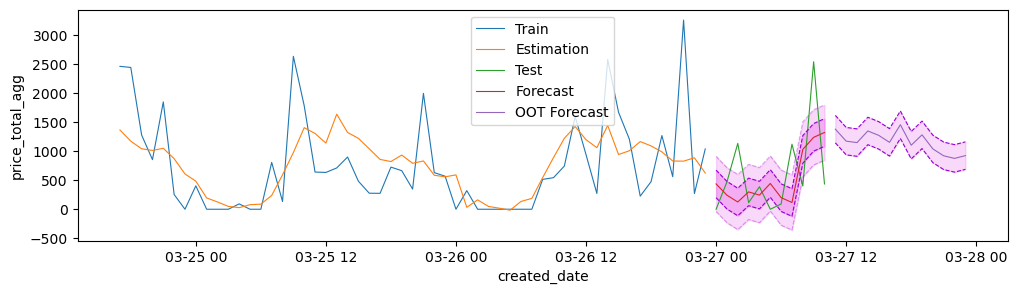

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 1.7383 - val_loss: 1.4125
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.3017 - val_loss: 1.2269
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.2338 - val_loss: 1.2114
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.2130 - val_loss: 1.2084
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.2148 - val_loss: 1.2150
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 1.1834 - val_loss: 1.2154
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 1.1963 - val_loss: 1.2058
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.1752 - val_loss: 1.2037
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 1.1688 - val_loss: 1.2050
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 1.1667 - val_loss: 1.2030
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 1.1566 - val_loss: 1.2007
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 1.1681 - val_loss: 1.1923
Epoch 13/1000
60

,feature,coef
0,tbats,0.428131
1,gb,0.848087
2,lstm,-0.141234


train RMSE: 1.454
train MAE:  1.027
test RMSE: 1.018
test MAE:  0.893


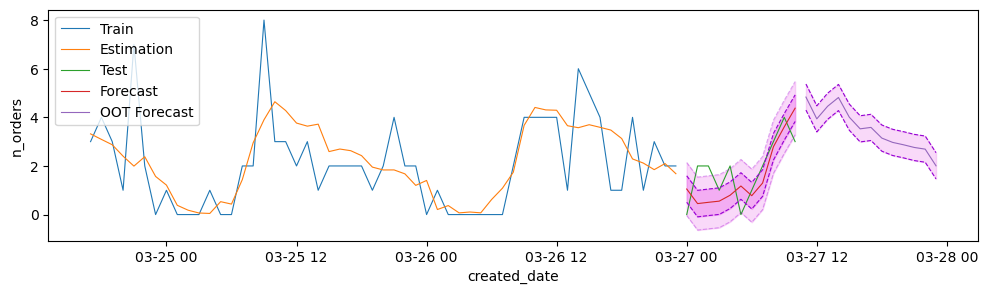

Processing account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 246.7185 - val_loss: 224.7276
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 246.5921 - val_loss: 224.7488
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 246.2416 - val_loss: 224.7857
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 245.5464 - val_loss: 224.8396
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 248.5922 - val_loss: 195.9803
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 248.4842 - val_loss: 196.0022
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 248.2168 - val_loss: 196.0430
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 247.6146 - val_loss: 196.0998
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━

,feature,coef
0,tbats,0.856330
1,gb,0.000000
2,lstm,6.064359


train RMSE: 496.035
train MAE:  244.494
test RMSE: 173.775
test MAE:  161.200


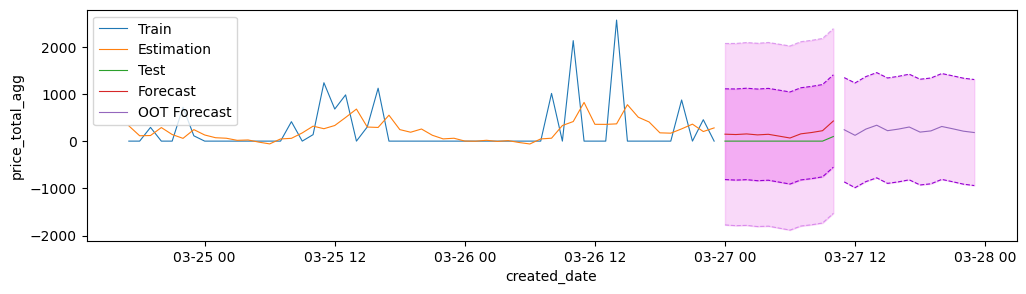

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1.0099 - val_loss: 0.4398
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.8549 - val_loss: 0.4401
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.7424 - val_loss: 0.4390
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.7339 - val_loss: 0.4389
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 0.7093 - val_loss: 0.4383
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 0.7271 - val_loss: 0.4385
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 0.7375 - val_loss: 0.4382
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 0.7414 - val_loss: 0.4380
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 0.6977 - val_loss: 0.4376
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 0.7002 - val_loss: 0.4376
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 0.6758 - val_loss: 0.4374
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 0.6982 - val_loss: 0.4375
Epoch 13/1000
60

,feature,coef
0,tbats,0.580455
1,gb,0.000000
2,lstm,1.132336


train RMSE: 1.463
train MAE:  0.707
test RMSE: 0.324
test MAE:  0.304


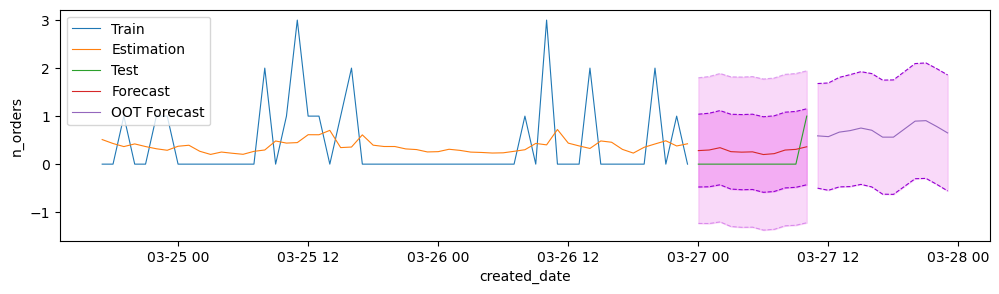

Processing account_id: 8fa00df1-38eb-426f-81a6-1185983e14cb, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 81.4455 - val_loss: 8.4247e-04
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 81.4331 - val_loss: 5.3453e-04
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 81.4257 - val_loss: 5.4345e-04
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 81.4223 - val_loss: 1.3562e-04
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 81.4128 - val_loss: 3.1147e-04
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 81.4093 - val_loss: 2.8483e-04
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 81.3961 - val_loss: 1.6536e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 81.0239 - val_loss: 1.8337e-04
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 81.0110 - val_loss: 0.0011
Epoch 3/1000
61

,feature,coef
0,tbats,0.609741
1,gb,0.000000
2,lstm,109.012209


train RMSE: 359.083
train MAE:  104.402
test RMSE: 56.810
test MAE:  56.068


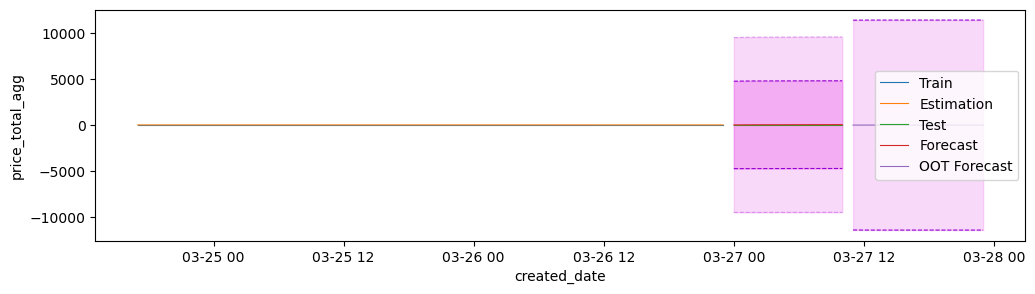

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 1.3585 - val_loss: 4.0643e-06
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.3390 - val_loss: 3.7025e-04
Epoch 3/1000
60/60 - 0s - 4ms/step - loss: 1.3306 - val_loss: 7.3476e-05
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3201 - val_loss: 8.4940e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Epoch 1/1000
61/61 - 2s - 25ms/step - loss: 1.3388 - val_loss: 5.5943e-04
Epoch 2/1000
61/61 - 0s - 3ms/step - loss: 1.3239 - val_loss: 0.0012
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3178 - val_loss: 5.8427e-04
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 1.3084 - val_loss: 4.8285e-05
Epoch 5/1000
61/61 - 0s - 3ms/step - loss: 1.3022 - val_loss: 5.9266e-05
Epoch 6/1000
61/61 - 0s - 3ms/step - loss: 1.2932 - val_loss: 8.2793e-04
Epoch 7/1000
61/61 - 0s - 3ms/step - loss: 

,feature,coef
0,tbats,0.677116
1,gb,0.000000
2,lstm,1.680495


train RMSE: 5.932
train MAE:  1.625
test RMSE: 0.850
test MAE:  0.840


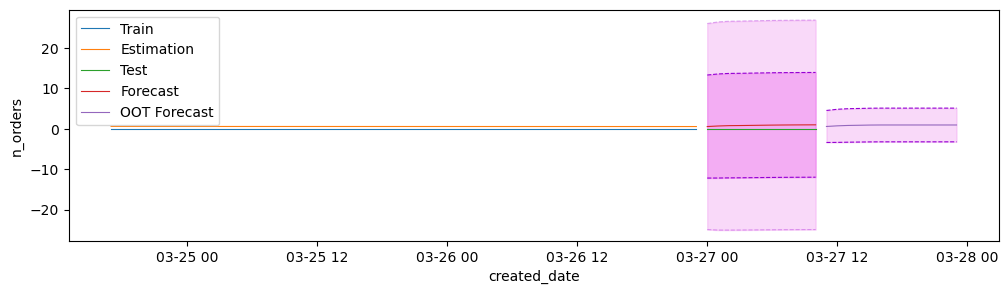

Processing account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 77.9753 - val_loss: 9483.2881
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 77.9747 - val_loss: 9483.2734
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 77.9747 - val_loss: 9483.2568
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 77.9747 - val_loss: 9483.2412
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 77.9746 - val_loss: 9483.2197
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.2012
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 77.9745 - val_loss: 9483.1582
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.1182
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 77.9745 - val_loss: 9483.0684
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 77.9744 - val_loss: 9483.0029
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,1.078109
1,gb,0.000000
2,lstm,38.146337


train RMSE: 30734.845
train MAE:  2861.454
test RMSE: 13571.593
test MAE:  13423.737


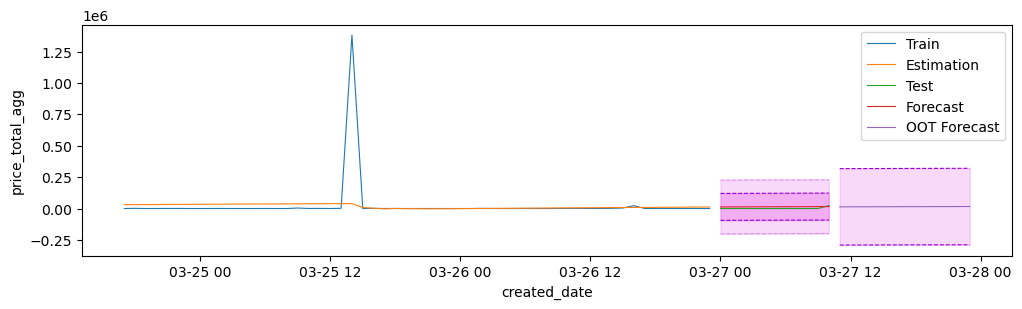

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 0.3626 - val_loss: 221.1032
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.1009
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.0988
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.0973
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0964
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0947
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0938
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0928
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0924
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 0.3619 - val_loss: 221.0922
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 221.0909
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.3618 - val_loss: 2

,feature,coef
0,tbats,1.034089
1,gb,0.000000
2,lstm,47.397524


train RMSE: 813.496
train MAE:  70.043
test RMSE: 659.731
test MAE:  659.260


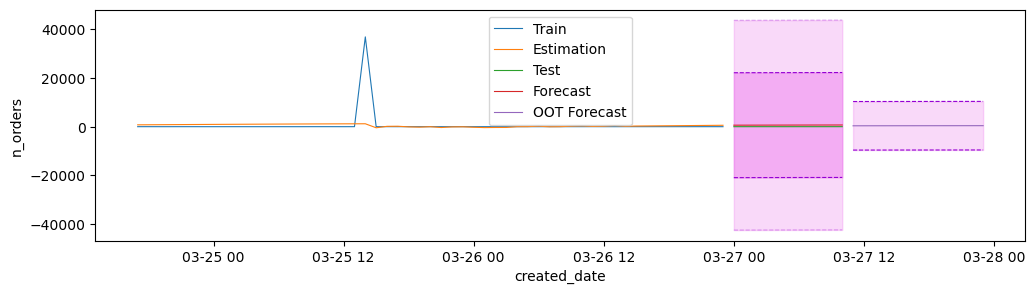

Processing account_id: 3dc15e4b-b60d-4c49-aae8-97cf9664af51, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 36.3375 - val_loss: 49.5126
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 36.3322 - val_loss: 49.4984
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 36.3215 - val_loss: 49.4922
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 36.3099 - val_loss: 49.4797
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 36.2992 - val_loss: 49.4750
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 36.2879 - val_loss: 49.4534
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 36.2614 - val_loss: 49.4290
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 36.2409 - val_loss: 49.3832
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 36.2263 - val_loss: 49.3594
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 36.2170 - val_loss: 49.3347
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 36

,feature,coef
0,tbats,0.624707
1,gb,0.000000
2,lstm,1.773441


train RMSE: 213.016
train MAE:  57.037
test RMSE: 36.919
test MAE:  36.618


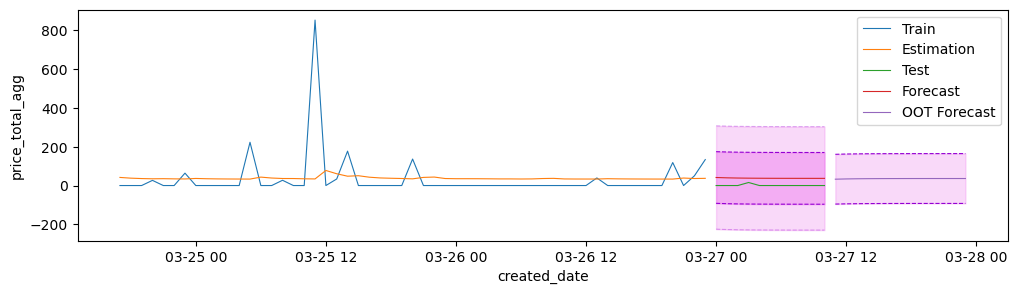

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 0.4382 - val_loss: 0.6351
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.4295 - val_loss: 0.6232
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.4215 - val_loss: 0.6309
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.4199 - val_loss: 0.6329
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 0.4199 - val_loss: 0.6211
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 0.4231 - val_loss: 0.6266
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.4196 - val_loss: 0.6266
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.4140 - val_loss: 0.6319
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 0.4367 - val_loss: 0.6321
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.4271 - val_loss: 0.6282
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.4220 - val_loss: 0.6261
Epoch 4/10

,feature,coef
0,tbats,0.866664
1,gb,0.000000
2,lstm,0.656605


train RMSE: 2.840
train MAE:  0.635
test RMSE: 0.484
test MAE:  0.483


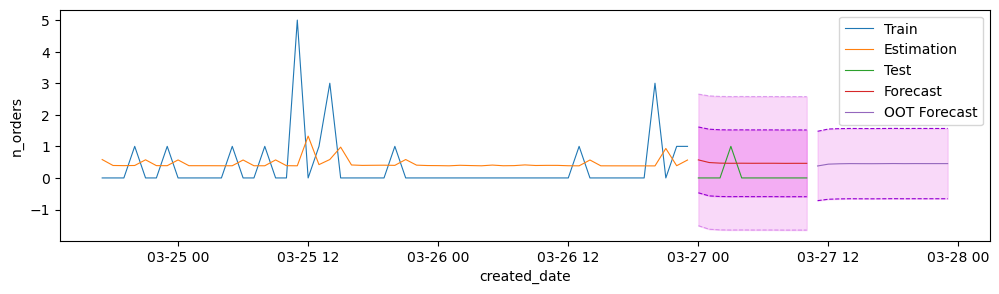

Processing account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 6368.9971 - val_loss: 5040.1006
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 6366.1436 - val_loss: 5036.3218
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 6358.1055 - val_loss: 5027.5254
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6343.2031 - val_loss: 5013.0874
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 6321.3472 - val_loss: 4993.1304
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 6292.9160 - val_loss: 4967.8545
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 6257.9536 - val_loss: 4937.4106
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 6216.7378 - val_loss: 4902.0811
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 6170.3145 - val_loss: 4862.3511
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 6116.4673 - val_loss: 4818.2305
Epoch 

,feature,coef
0,tbats,-0.141058
1,gb,1.524655
2,lstm,-0.241478


train RMSE: 1739.990
train MAE:  1001.074
test RMSE: 2104.551
test MAE:  1228.304


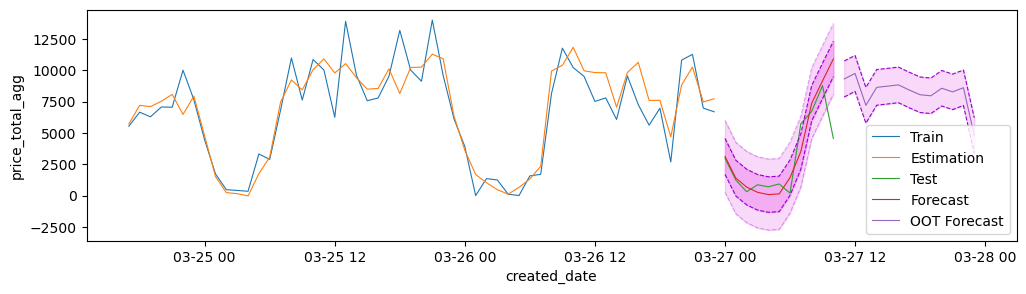

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 16.0357 - val_loss: 12.8519
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 14.1948 - val_loss: 10.3353
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 9.4868 - val_loss: 5.6431
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 5.7184 - val_loss: 4.4936
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 5.3622 - val_loss: 4.3791
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 5.3099 - val_loss: 4.3262
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 5.1520 - val_loss: 4.2895
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 5.2063 - val_loss: 4.2359
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 5.0612 - val_loss: 4.1877
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 4.9518 - val_loss: 4.1262
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 4.9688 - val_loss: 4.1070
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 4.8003 - val_loss: 4.0995
Epoch 13/100

,feature,coef
0,tbats,-0.074164
1,gb,1.346259
2,lstm,-0.098143


train RMSE: 4.633
train MAE:  2.813
test RMSE: 4.043
test MAE:  2.575


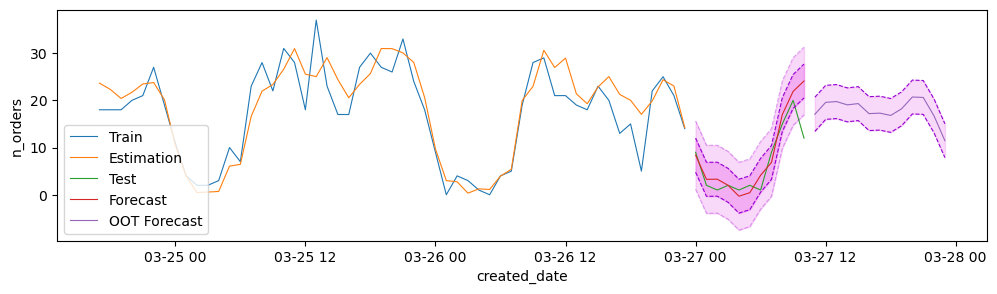

Processing account_id: e2de40dd-743b-4105-9077-3f343fea980d, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 2971.1948 - val_loss: 3025.2080
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2969.8428 - val_loss: 3022.7412
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 2965.4436 - val_loss: 3015.8188
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2955.7520 - val_loss: 3003.0715
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2940.7566 - val_loss: 2984.9988
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 2920.6890 - val_loss: 2961.7852
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 2895.1729 - val_loss: 2933.6130
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 2864.7046 - val_loss: 2900.7649
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 2830.0701 - val_loss: 2862.9946
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2788.9756 - val_loss: 2819.8210
Epoch 

,feature,coef
0,tbats,0.239844
1,gb,1.098917
2,lstm,-0.217407


train RMSE: 1938.456
train MAE:  1112.893
test RMSE: 1727.875
test MAE:  1356.166


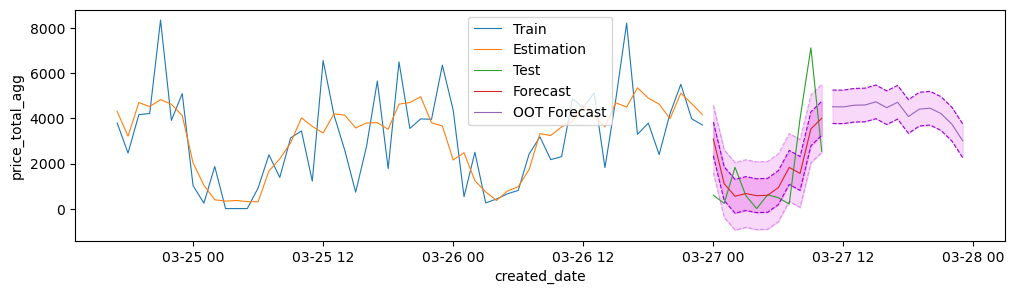

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 9.7925 - val_loss: 7.7492
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 8.7944 - val_loss: 6.2467
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 6.6107 - val_loss: 4.1118
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 4.7524 - val_loss: 3.5474
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 4.2774 - val_loss: 3.3998
Epoch 6/1000
60/60 - 0s - 4ms/step - loss: 4.2245 - val_loss: 3.3569
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 4.1771 - val_loss: 3.3418
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 4.0780 - val_loss: 3.2992
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 4.0299 - val_loss: 3.2850
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 4.0274 - val_loss: 3.2658
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 4.0303 - val_loss: 3.2473
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4.0465 - val_loss: 3.2561
Epoch 13/1000
60

,feature,coef
0,tbats,0.331641
1,gb,0.634910
2,lstm,0.136751


train RMSE: 4.952
train MAE:  3.236
test RMSE: 2.497
test MAE:  2.110


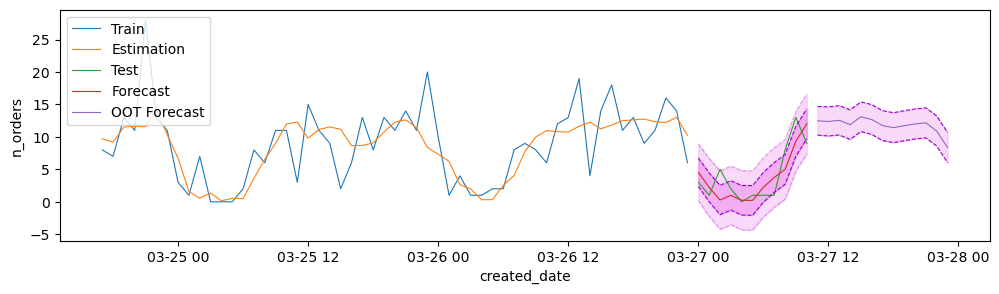

Processing account_id: f9129295-bb08-4330-b60c-9f0beadda521, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 528770.6875 - val_loss: 511753.1562
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 528765.4375 - val_loss: 511744.1875
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 528751.5000 - val_loss: 511725.9688
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 528729.0625 - val_loss: 511700.1250
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 528699.3125 - val_loss: 511667.1875
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 528663.3750 - val_loss: 511628.2812
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 528618.0625 - val_loss: 511582.1250
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 528568.9375 - val_loss: 511529.2812
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 528511.4375 - val_loss: 511469.7500
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 52

,feature,coef
0,tbats,0.022187
1,gb,1.136833
2,lstm,-0.125087


train RMSE: 74680.302
train MAE:  34524.531
test RMSE: 36062.519
test MAE:  30555.479


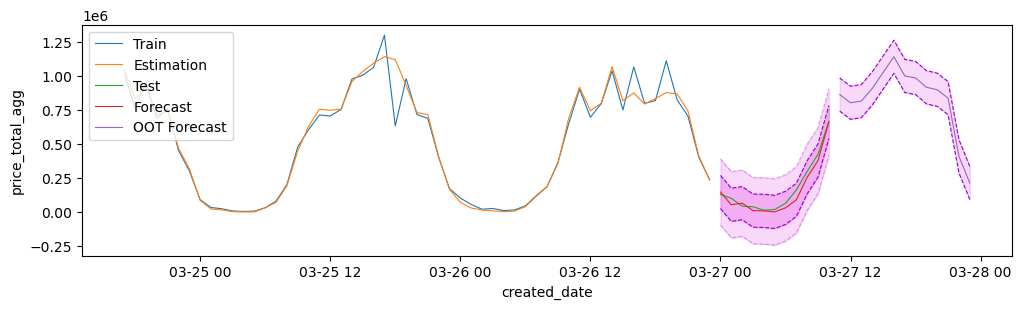

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 192.7253 - val_loss: 179.8882
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 186.5600 - val_loss: 170.3831
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 172.5580 - val_loss: 153.2992
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 151.6059 - val_loss: 129.8701
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 125.5894 - val_loss: 102.9653
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 95.6057 - val_loss: 73.3181
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 67.9382 - val_loss: 43.5411
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 47.3751 - val_loss: 31.8434
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 43.3081 - val_loss: 30.4766
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 43.9580 - val_loss: 29.9968
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 42.4306 - val_loss: 29.6589
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 41.2532 - 

,feature,coef
0,tbats,0.016752
1,gb,1.111621
2,lstm,-0.105795


train RMSE: 16.579
train MAE:  8.675
test RMSE: 18.480
test MAE:  11.688


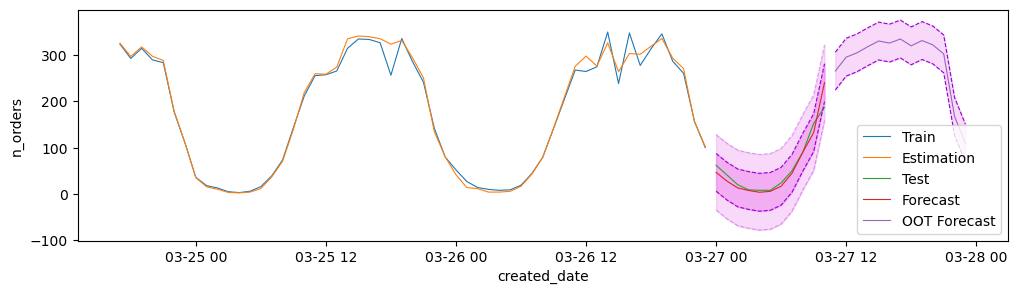

Processing account_id: 0661e926-f219-456e-bde5-612fee6f891c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 555.0818 - val_loss: 968.2425
Epoch 2/1000
60/60 - 0s - 8ms/step - loss: 554.7311 - val_loss: 967.8267
Epoch 3/1000
60/60 - 0s - 5ms/step - loss: 554.0363 - val_loss: 967.0349
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 552.6215 - val_loss: 965.6599
Epoch 5/1000
60/60 - 0s - 4ms/step - loss: 550.2969 - val_loss: 963.5310
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 547.0912 - val_loss: 960.5266
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 542.6890 - val_loss: 956.6193
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 537.0980 - val_loss: 951.7446
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 531.0311 - val_loss: 945.8863
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 523.9267 - val_loss: 939.1965
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.194124
1,gb,0.476936
2,lstm,0.815000


train RMSE: 864.089
train MAE:  375.735
test RMSE: 388.190
test MAE:  285.948


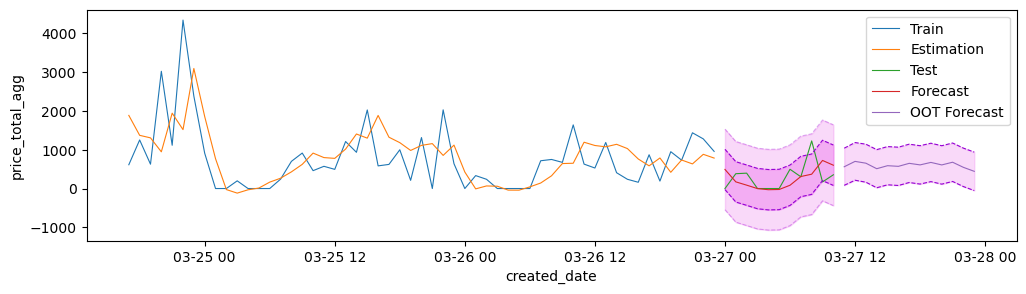

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 27ms/step - loss: 2.6397 - val_loss: 4.9941
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2.3847 - val_loss: 4.7401
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.2332 - val_loss: 4.4550
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.1175 - val_loss: 4.1397
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.0739 - val_loss: 3.9313
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2.0353 - val_loss: 3.7765
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 2.0300 - val_loss: 3.6779
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.9809 - val_loss: 3.6055
Epoch 9/1000
60/60 - 0s - 4ms/step - loss: 1.9477 - val_loss: 3.5039
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.9296 - val_loss: 3.3836
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.8983 - val_loss: 3.3248
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.8627 - val_loss: 3.2296
Epoch 13/1000
60

,feature,coef
0,tbats,-0.547127
1,gb,0.580502
2,lstm,1.595211


train RMSE: 5.099
train MAE:  1.784
test RMSE: 1.495
test MAE:  1.219


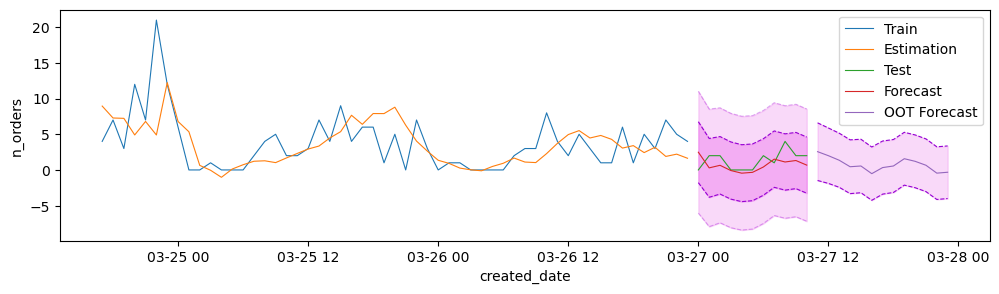

Processing account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 495.7666 - val_loss: 588.0311
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 494.1538 - val_loss: 585.0226
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 489.1482 - val_loss: 577.2523
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 479.2513 - val_loss: 563.8983
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 463.7925 - val_loss: 544.9837
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 444.0285 - val_loss: 521.0721
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 421.7635 - val_loss: 494.2004
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 397.0001 - val_loss: 466.0613
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 373.4556 - val_loss: 438.2446
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 350.4465 - val_loss: 411.8708
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.330462
1,gb,1.007000
2,lstm,-0.128846


train RMSE: 347.500
train MAE:  225.435
test RMSE: 253.642
test MAE:  179.354


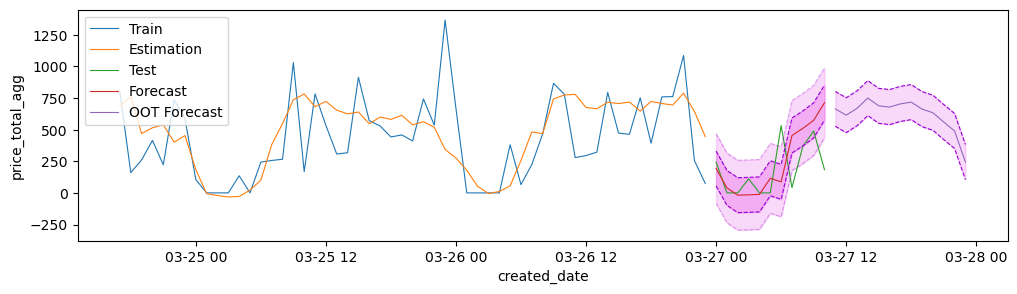

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 3.8257 - val_loss: 3.6665
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2.5910 - val_loss: 2.0550
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.9507 - val_loss: 1.8111
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.8959 - val_loss: 1.8127
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.8764 - val_loss: 1.7988
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.8667 - val_loss: 1.7835
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.8427 - val_loss: 1.7766
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.8306 - val_loss: 1.7792
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.8248 - val_loss: 1.7601
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.8370 - val_loss: 1.7488
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 1.8226 - val_loss: 1.7541
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 1.7978 - val_loss: 1.7418
Epoch 13/1000
60

,feature,coef
0,tbats,0.548884
1,gb,0.250550
2,lstm,0.257161


train RMSE: 2.394
train MAE:  1.643
test RMSE: 1.626
test MAE:  1.157


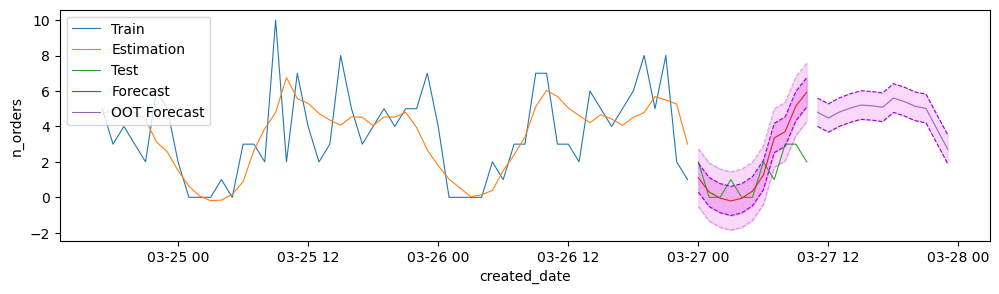

Processing account_id: d639773a-df2c-421e-ac87-6918a754572f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 447.6578 - val_loss: 765.9483
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 447.6436 - val_loss: 765.9363
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 447.6187 - val_loss: 765.8937
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 447.5849 - val_loss: 765.8307
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 447.5309 - val_loss: 765.7114
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 447.4583 - val_loss: 765.5956
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 447.3476 - val_loss: 765.3380
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 447.2096 - val_loss: 765.1221
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 447.0154 - val_loss: 764.8478
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 446.8524 - val_loss: 764.4436
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.490852
1,gb,0.000000
2,lstm,1.823352


train RMSE: 1181.442
train MAE:  524.146
test RMSE: 987.197
test MAE:  788.848


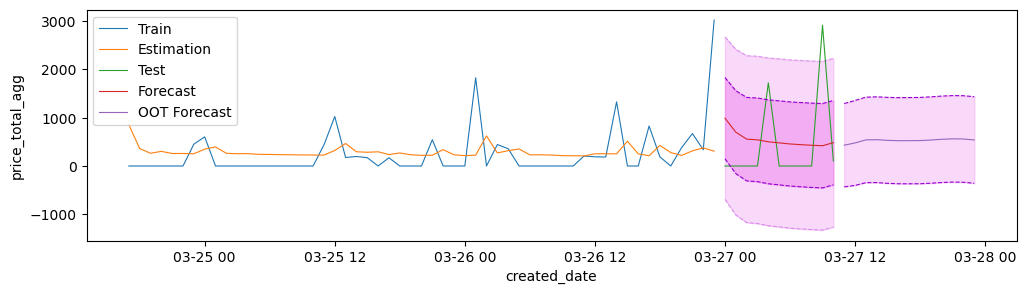

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 2.5124 - val_loss: 1.2155
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 2.4877 - val_loss: 1.2153
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.4548 - val_loss: 1.2130
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.4077 - val_loss: 1.2120
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2.3327 - val_loss: 1.2081
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 2.2655 - val_loss: 1.2065
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 2.1828 - val_loss: 1.2007
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 2.1883 - val_loss: 1.2004
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 2.1084 - val_loss: 1.1936
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2.0532 - val_loss: 1.1935
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 2.0347 - val_loss: 1.1857
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 1.9627 - val_loss: 1.1873
Epoch 13/1000
60

,feature,coef
0,tbats,0.246344
1,gb,0.000000
2,lstm,0.943454


train RMSE: 6.294
train MAE:  1.980
test RMSE: 1.367
test MAE:  1.220


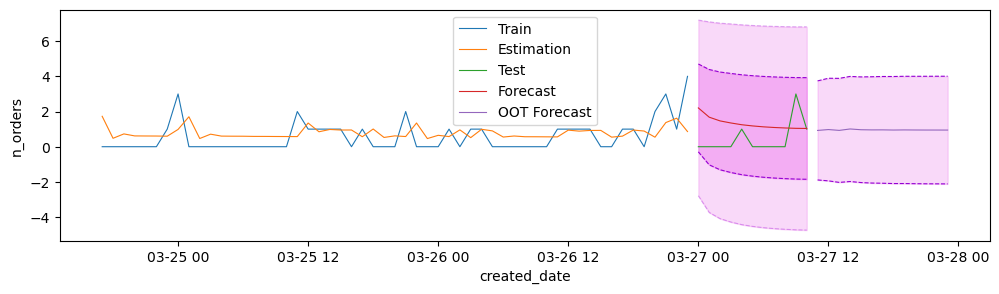

Processing account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 45589.3555 - val_loss: 60534.2969
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 45585.3359 - val_loss: 60525.3477
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 45574.3477 - val_loss: 60505.9375
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 45554.4375 - val_loss: 60476.2188
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 45525.5664 - val_loss: 60436.0000
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 45488.8086 - val_loss: 60386.2031
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 45442.5938 - val_loss: 60327.3242
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 45388.4609 - val_loss: 60259.8750
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 45329.1914 - val_loss: 60185.1445
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 45263.5312 - val_los

,feature,coef
0,tbats,-0.001316
1,gb,1.198779
2,lstm,-0.147682


train RMSE: 7575.081
train MAE:  3274.909
test RMSE: 15939.399
test MAE:  9099.200


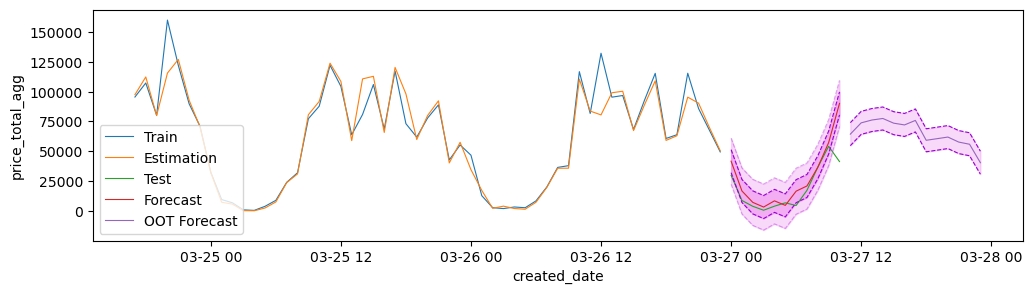

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 71.2162 - val_loss: 77.1780
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 68.4182 - val_loss: 72.1581
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 61.4257 - val_loss: 61.0813
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 48.3074 - val_loss: 42.3160
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 30.3198 - val_loss: 18.7387
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 18.1929 - val_loss: 12.4474
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 16.9905 - val_loss: 12.3876
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 16.0942 - val_loss: 12.1284
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 16.1955 - val_loss: 11.8610
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 16.4305 - val_loss: 11.7243
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 15.7020 - val_loss: 11.5671
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 15.7902 - val_loss: 

,feature,coef
0,tbats,0.069642
1,gb,1.192888
2,lstm,-0.202616


train RMSE: 10.663
train MAE:  6.858
test RMSE: 16.729
test MAE:  9.850


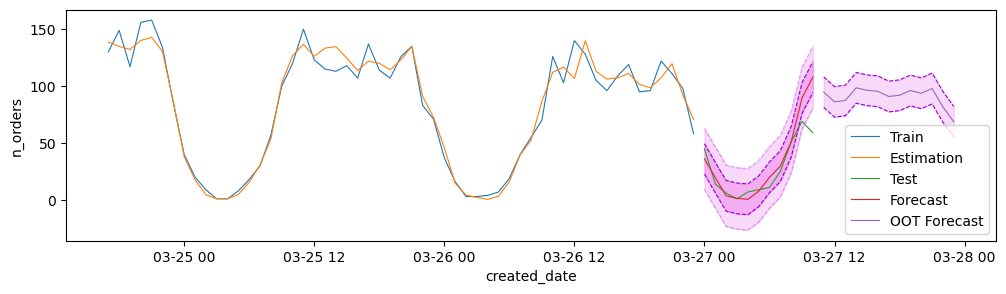

Processing account_id: 60ca8452-5b14-481f-a637-8756f527aee8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 275.6755 - val_loss: 0.0028
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 275.6227 - val_loss: 3.4202e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 275.5565 - val_loss: 1.5304e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 275.3957 - val_loss: 4.6577e-05
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 275.1190 - val_loss: 2.9586e-05
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 274.7385 - val_loss: 1.9422e-04
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 274.2021 - val_loss: 1.4890e-04
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 273.7007 - val_loss: 2.9391e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 274.2469 - val_loss: 0.0010
Epoch 2/1000

,feature,coef
0,tbats,0.989288
1,gb,0.000000
2,lstm,-0.485690


train RMSE: 894.755
train MAE:  220.322
test RMSE: 9.854
test MAE:  9.854


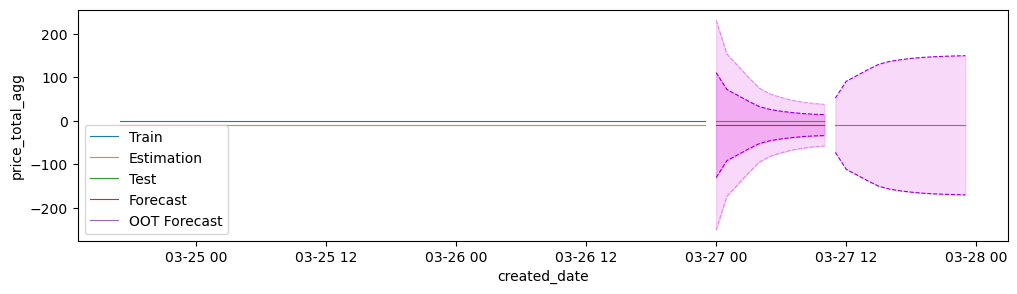

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 1.4010 - val_loss: 6.2318e-04
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 1.3660 - val_loss: 1.6338e-04
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 1.3437 - val_loss: 1.8544e-05
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 1.3040 - val_loss: 2.5983e-05
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.2522 - val_loss: 2.3725e-04
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.2159 - val_loss: 1.4058e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 1.4115 - val_loss: 7.1253e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 1.3692 - val_loss: 1.0562e-04
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.3393 - val_loss: 4.7641e-04
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 1.3174 - val_loss: 3.0837e-04
Epoch 5/1000
61/61 - 0s - 3ms/step - lo

,feature,coef
0,tbats,0.980113
1,gb,0.000000
2,lstm,0.003621


train RMSE: 4.334
train MAE:  1.103
test RMSE: 0.055
test MAE:  0.055


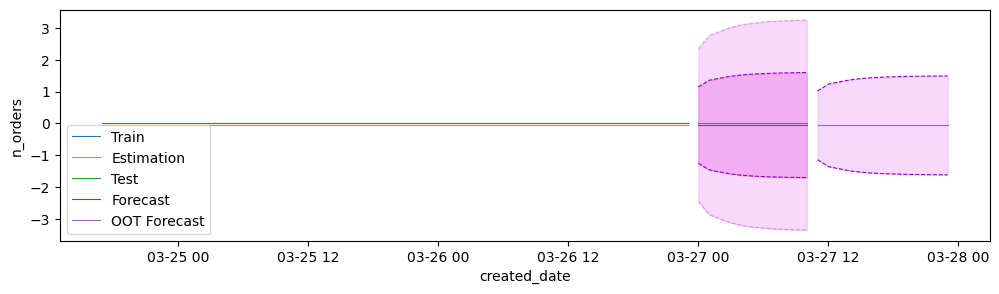

Processing account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1304.5555 - val_loss: 764.0727
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1303.1179 - val_loss: 762.7587
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1298.5018 - val_loss: 759.2657
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1289.3271 - val_loss: 752.9096
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1274.9641 - val_loss: 743.3106
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1256.2357 - val_loss: 730.6705
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1233.0142 - val_loss: 715.4579
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1205.6558 - val_loss: 697.5613
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1175.4043 - val_loss: 677.2657
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1139.9833 - val_loss: 654.9498
Epoch 11/1000
60

,feature,coef
0,tbats,0.559524
1,gb,0.599773
2,lstm,-0.040949


train RMSE: 947.482
train MAE:  631.122
test RMSE: 737.388
test MAE:  529.935


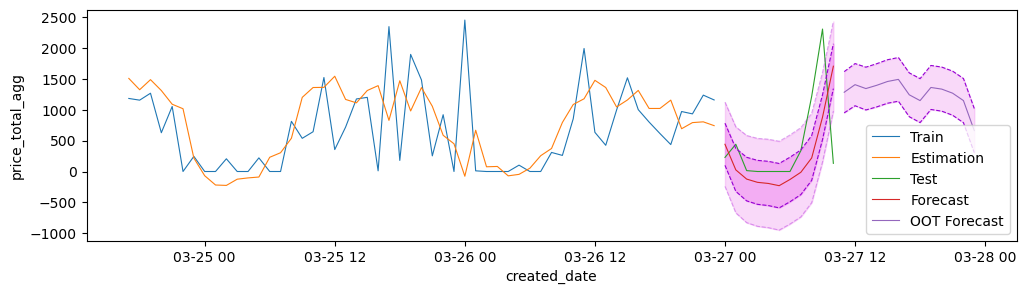

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 16ms/step - loss: 3.6794 - val_loss: 2.1144
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 2.5296 - val_loss: 1.4840
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.1110 - val_loss: 1.4156
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.0049 - val_loss: 1.3941
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 1.9751 - val_loss: 1.3967
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 1.9366 - val_loss: 1.3911
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 1.9299 - val_loss: 1.3856
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 1.9103 - val_loss: 1.3771
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 1.9184 - val_loss: 1.3731
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 1.8610 - val_loss: 1.3873
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 1.8513 - val_loss: 1.3801
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 1.8741 - val_loss: 1.3863
67/67 ━━━━━━━━━━

,feature,coef
0,tbats,0.274087
1,gb,0.781963
2,lstm,0.125982


train RMSE: 2.588
train MAE:  1.661
test RMSE: 2.023
test MAE:  1.367


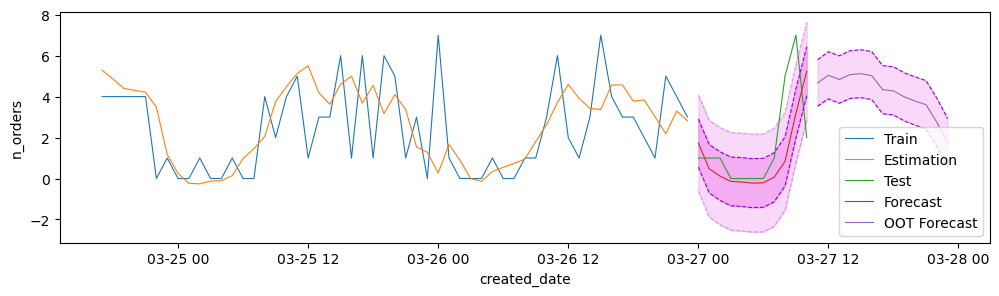

Processing account_id: 7db6eaca-fe22-41d7-bfb8-1fdde880feb8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 19ms/step - loss: 287.8134 - val_loss: 245.3964
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 287.7498 - val_loss: 245.3448
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 287.6726 - val_loss: 245.2675
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 287.5193 - val_loss: 245.1555
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 287.2806 - val_loss: 245.0045
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 286.9117 - val_loss: 244.8144
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 286.5310 - val_loss: 244.5920
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 286.1501 - val_loss: 244.3224
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 285.8017 - val_loss: 243.9996
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 285.4517 - val_loss: 243.6516
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.624308
1,gb,0.279125
2,lstm,0.400326


train RMSE: 891.652
train MAE:  207.573
test RMSE: 128.823
test MAE:  120.093


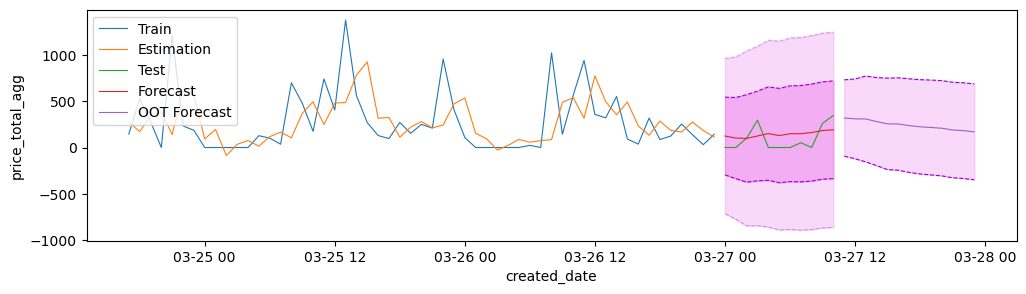

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 24ms/step - loss: 1.3293 - val_loss: 2.1568
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.1867 - val_loss: 1.8955
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.0593 - val_loss: 1.7007
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.9937 - val_loss: 1.6235
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.9750 - val_loss: 1.5883
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.9530 - val_loss: 1.5239
Epoch 7/1000
60/60 - 0s - 4ms/step - loss: 0.9458 - val_loss: 1.5302
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9331 - val_loss: 1.4489
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.9369 - val_loss: 1.4675
Epoch 10/1000
60/60 - 0s - 4ms/step - loss: 0.9198 - val_loss: 1.4471
Epoch 11/1000
60/60 - 0s - 4ms/step - loss: 0.9088 - val_loss: 1.4069
Epoch 12/1000
60/60 - 0s - 5ms/step - loss: 0.9107 - val_loss: 1.3980
Epoch 13/1000
60

,feature,coef
0,tbats,0.265998
1,gb,0.144260
2,lstm,0.662328


train RMSE: 1.461
train MAE:  0.924
test RMSE: 0.972
test MAE:  0.860


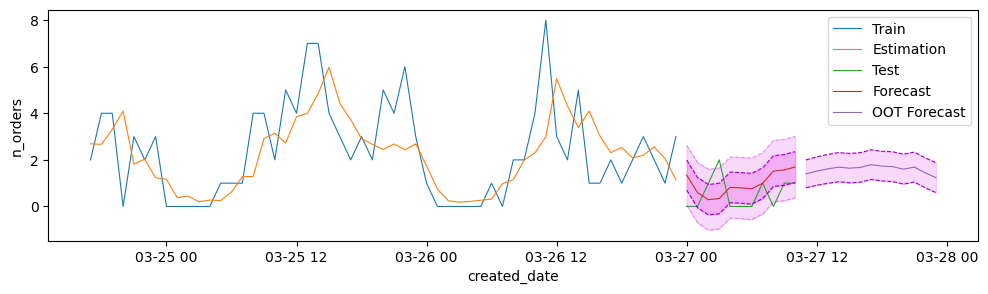

Processing account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 822.7852 - val_loss: 617.5591
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 822.1000 - val_loss: 616.5618
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 819.7991 - val_loss: 613.7306
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 814.6639 - val_loss: 608.4611
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 806.6448 - val_loss: 600.7416
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 795.8006 - val_loss: 590.6057
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 782.6581 - val_loss: 578.9992
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 767.8078 - val_loss: 566.2421
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 752.4236 - val_loss: 552.7890
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 736.1398 - val_loss: 539.5499
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.652744
1,gb,0.284744
2,lstm,0.209192


train RMSE: 852.504
train MAE:  574.173
test RMSE: 382.874
test MAE:  283.719


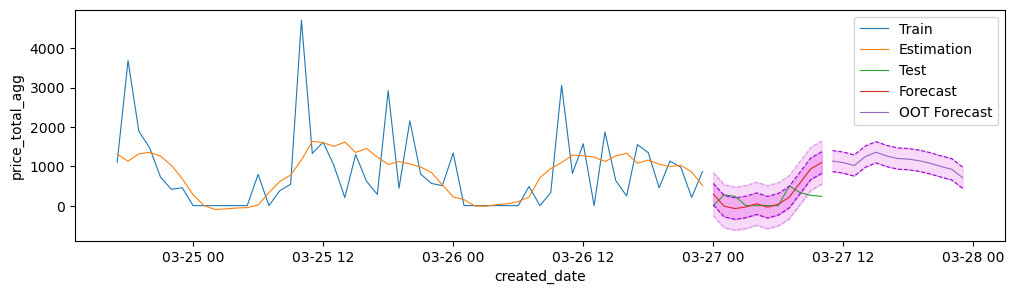

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 1.8785 - val_loss: 1.2128
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.4288 - val_loss: 1.0462
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.3904 - val_loss: 1.0289
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.3544 - val_loss: 1.0297
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.3307 - val_loss: 1.0284
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 1.3287 - val_loss: 1.0328
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 1.3047 - val_loss: 1.0354
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.3120 - val_loss: 1.0357
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 1.9382 - val_loss: 1.2798
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 1.4662 - val_loss: 1.0599
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 1.3740 - val_loss: 1.0355
Epoch 4/10

,feature,coef
0,tbats,0.260575
1,gb,0.864355
2,lstm,0.084535


train RMSE: 1.710
train MAE:  1.182
test RMSE: 0.961
test MAE:  0.751


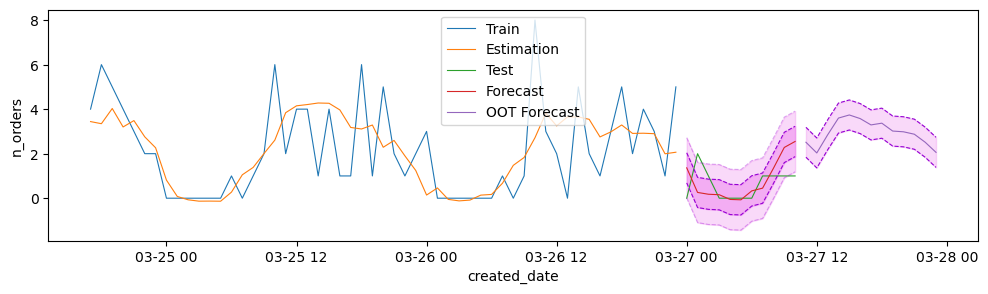

Processing account_id: 457bce7b-9300-4c10-9a97-070b3c0d081d, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1214.6624 - val_loss: 1753.0114
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1214.6337 - val_loss: 1752.9425
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1214.5924 - val_loss: 1752.8081
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1214.5266 - val_loss: 1752.5562
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1214.3870 - val_loss: 1752.0846
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1214.1954 - val_loss: 1751.3665
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1213.8285 - val_loss: 1750.2837
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1213.3909 - val_loss: 1748.8574
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1212.8151 - val_loss: 1747.0792
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1211.9479 - val_loss: 1744.8796
Epoch 

,feature,coef
0,tbats,0.887113
1,gb,0.000000
2,lstm,0.180183


train RMSE: 2040.173
train MAE:  1297.685
test RMSE: 4635.934
test MAE:  2469.786


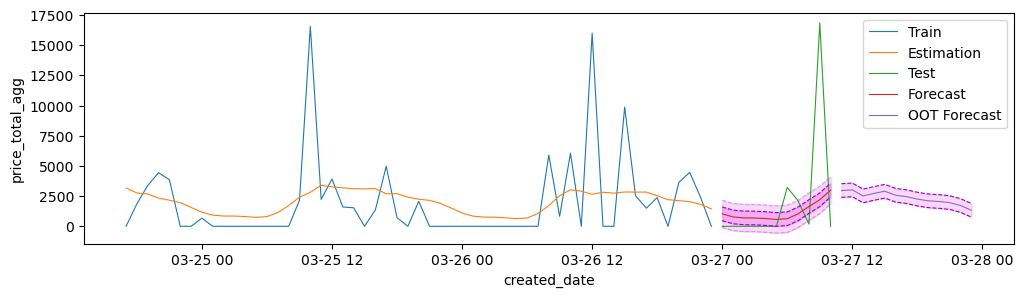

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.5987 - val_loss: 0.7407
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.5672 - val_loss: 0.6878
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.5543 - val_loss: 0.6827
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.5529 - val_loss: 0.6820
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.5438 - val_loss: 0.6844
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.5422 - val_loss: 0.6828
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 0.5384 - val_loss: 0.6838
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 0.5953 - val_loss: 0.7527
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 0.5704 - val_loss: 0.7054
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 0.5521 - val_loss: 0.6998
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 0.5487 - val_loss: 0.6970
Epoch 5/10

,feature,coef
0,tbats,0.614188
1,gb,0.000000
2,lstm,0.504299


train RMSE: 0.823
train MAE:  0.571
test RMSE: 0.764
test MAE:  0.592


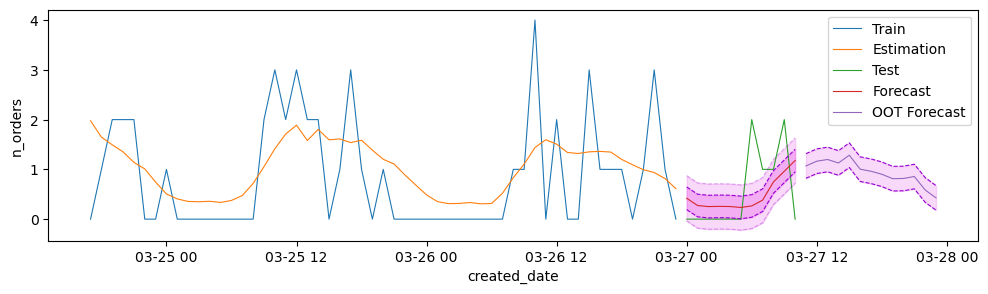

Processing account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 17ms/step - loss: 34637.7383 - val_loss: 30492.8945
Epoch 2/1000
60/60 - 0s - 3ms/step - loss: 34633.5664 - val_loss: 30485.9453
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 34622.0977 - val_loss: 30471.2070
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 34602.2070 - val_loss: 30448.2676
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 34573.2305 - val_loss: 30417.4141
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 34538.0703 - val_loss: 30379.4766
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 34494.6875 - val_loss: 30334.5215
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 34443.8906 - val_loss: 30282.3828
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 34384.3867 - val_loss: 30222.9785
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 34322.5703 - val_los

,feature,coef
0,tbats,0.139718
1,gb,1.220792
2,lstm,-0.276092


train RMSE: 11648.392
train MAE:  6918.353
test RMSE: 4425.389
test MAE:  3189.242


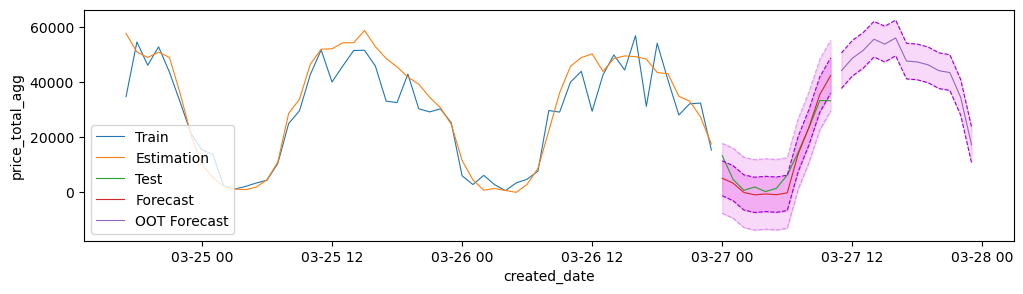

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 110.5068 - val_loss: 93.6588
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 106.7959 - val_loss: 88.3012
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 98.0724 - val_loss: 77.5273
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 82.9943 - val_loss: 60.4471
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 62.7561 - val_loss: 38.1373
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 40.5744 - val_loss: 18.0945
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 30.5531 - val_loss: 15.2951
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 28.7459 - val_loss: 14.5985
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 29.1600 - val_loss: 14.0307
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 28.3685 - val_loss: 13.9963
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 27.7932 - val_loss: 13.7176
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 27.6806 - val_loss

,feature,coef
0,tbats,0.696024
1,gb,0.722582
2,lstm,-0.370146


train RMSE: 29.692
train MAE:  15.947
test RMSE: 11.161
test MAE:  6.603


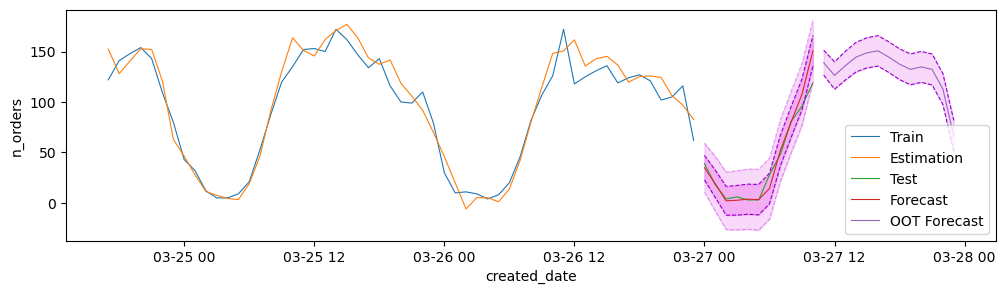

Processing account_id: 2058f680-aace-4b31-aed4-f34397b75096, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 25ms/step - loss: 0.0616 - val_loss: 1.2899e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0587 - val_loss: 6.8768e-05
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0553 - val_loss: 2.0281e-04
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0546 - val_loss: 2.5467e-05
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.0575 - val_loss: 1.0621e-06
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.0505 - val_loss: 2.2420e-04
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.0527 - val_loss: 3.2001e-05
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 0.0528 - val_loss: 1.1868e-04
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 0.0599 - val_loss: 1.6080e-04
Epoch 2/1000
61/61 - 0

,feature,coef
0,tbats,1.059549
1,gb,0.000000
2,lstm,0.108984


train RMSE: 1.297
train MAE:  0.158
test RMSE: 0.073
test MAE:  0.059


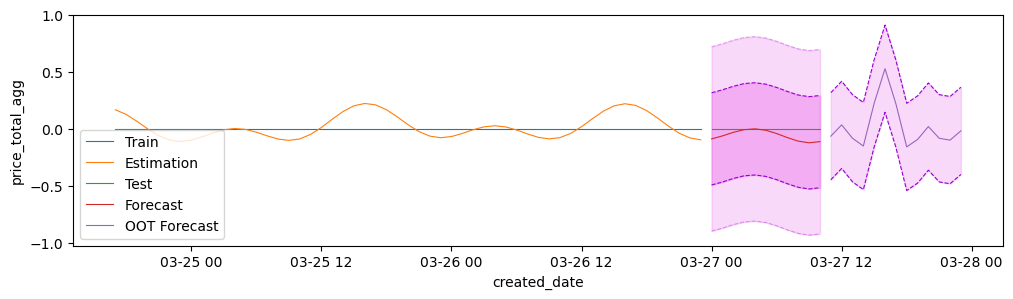

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0255 - val_loss: 1.8578e-04
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0207 - val_loss: 1.2482e-04
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0159 - val_loss: 1.2893e-04
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0195 - val_loss: 4.3052e-07
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.0193 - val_loss: 4.2057e-05
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.0193 - val_loss: 8.5099e-05
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.0205 - val_loss: 3.6528e-05
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 0.0186 - val_loss: 1.1264e-04
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0166 - val_loss: 1.9477e-04
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0167 - val_loss: 1.4615e-04
Epoch 4/1000
61/61 - 0s - 2ms/step - lo

,feature,coef
0,tbats,1.312338
1,gb,0.000000
2,lstm,0.002777


train RMSE: 0.030
train MAE:  0.004
test RMSE: 0.001
test MAE:  0.001


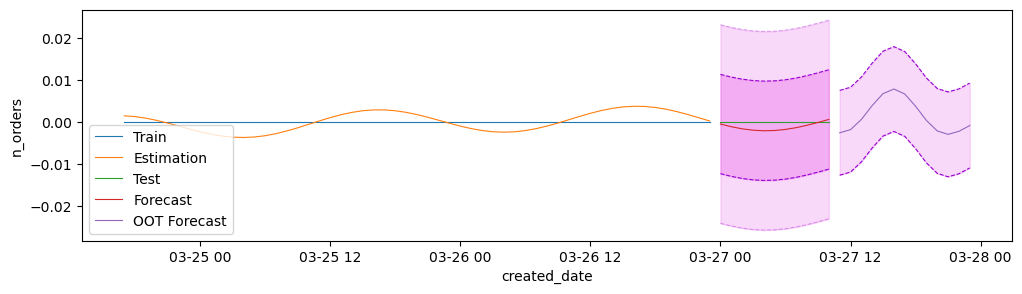

Processing account_id: f4471620-212b-4991-98d3-b498835d0c29, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


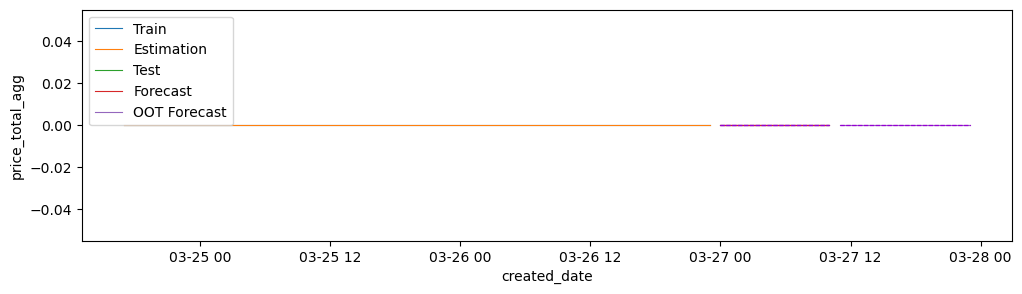

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/ste

,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


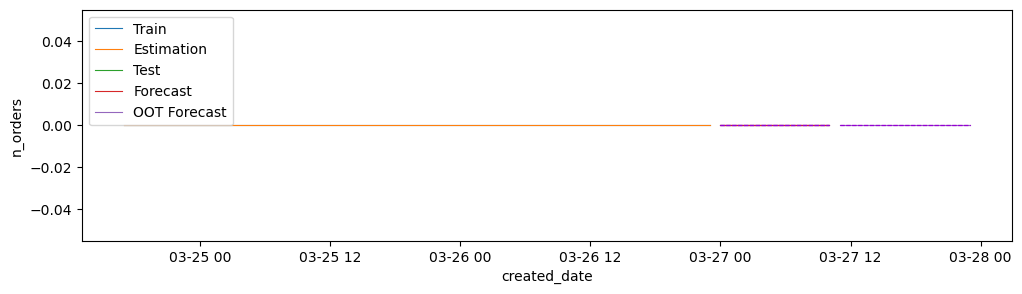

Processing account_id: 789ff5c4-21d8-4ed3-ab64-8b46cf2eba9b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 20ms/step - loss: 255.2344 - val_loss: 209.7323
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 255.0656 - val_loss: 209.5694
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 254.7370 - val_loss: 209.2522
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 254.1684 - val_loss: 208.6918
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 253.1547 - val_loss: 207.7928
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 251.7092 - val_loss: 206.5007
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 249.8384 - val_loss: 204.7969
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 247.6141 - val_loss: 202.6317
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 245.2710 - val_loss: 199.9850
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 242.2952 - val_loss: 196.9393
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.662394
1,gb,0.287344
2,lstm,0.554338


train RMSE: 602.499
train MAE:  223.403
test RMSE: 186.958
test MAE:  166.274


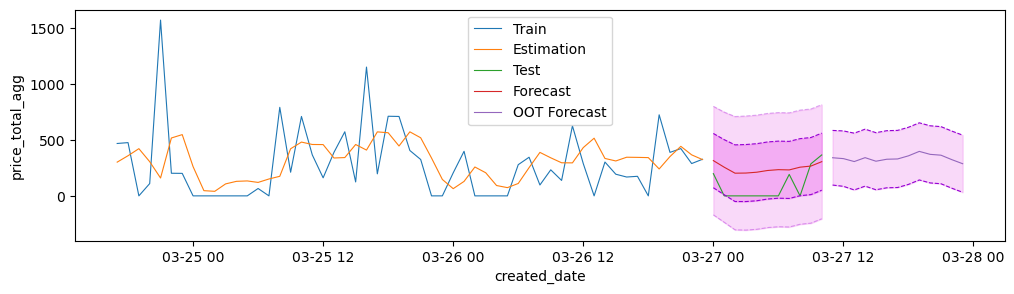

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 2.0787 - val_loss: 1.3471
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.9911 - val_loss: 1.2652
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1.8958 - val_loss: 1.1450
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 1.8315 - val_loss: 1.0763
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 1.8021 - val_loss: 1.0589
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 1.7553 - val_loss: 1.0381
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 1.7376 - val_loss: 1.0135
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 1.6951 - val_loss: 0.9980
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 1.6684 - val_loss: 0.9800
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 1.6466 - val_loss: 0.9699
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 1.6439 - val_loss: 0.9665
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 1.6274 - val_loss: 0.9595
Epoch 13/1000
60

,feature,coef
0,tbats,-0.019241
1,gb,-0.915763
2,lstm,2.604171


train RMSE: 7.572
train MAE:  1.720
test RMSE: 0.805
test MAE:  0.614


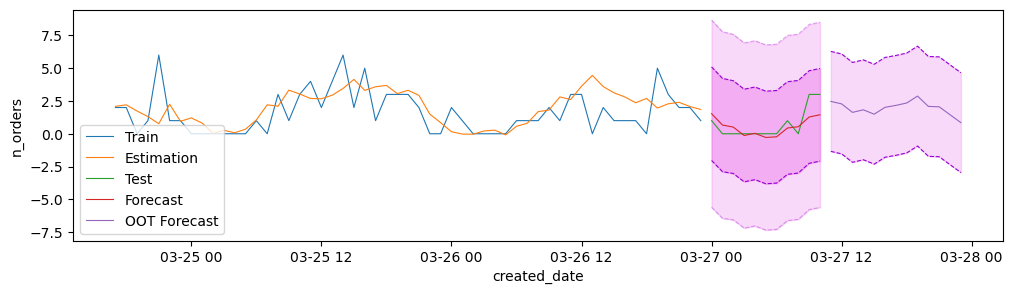

Processing account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 5113.6621 - val_loss: 3986.7314
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 5112.5630 - val_loss: 3985.0581
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 5109.3550 - val_loss: 3980.7583
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 5102.6816 - val_loss: 3972.9272
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 5092.1626 - val_loss: 3961.4512
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 5077.3774 - val_loss: 3946.2256
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 5059.4995 - val_loss: 3927.6179
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 5038.0195 - val_loss: 3906.0496
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 5013.7427 - val_loss: 3881.5698
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4984.7188 - val_loss: 3854.2659
Epoch 

,feature,coef
0,tbats,0.607518
1,gb,0.527712
2,lstm,-0.025974


train RMSE: 2901.939
train MAE:  1912.483
test RMSE: 1381.414
test MAE:  1009.324


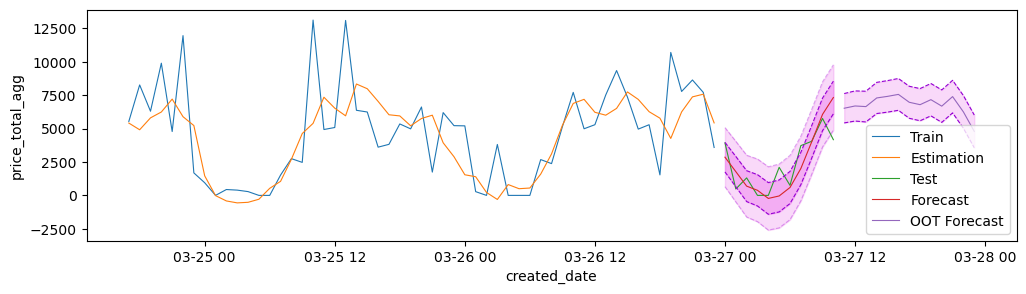

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 12.1194 - val_loss: 7.7625
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 11.1307 - val_loss: 6.2469
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 8.9162 - val_loss: 4.1420
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 6.2556 - val_loss: 3.2652
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 5.3519 - val_loss: 3.0940
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 5.1642 - val_loss: 3.0768
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 5.0318 - val_loss: 3.0617
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 4.9689 - val_loss: 3.0303
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 4.8704 - val_loss: 3.0206
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 4.7693 - val_loss: 3.0110
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 4.7332 - val_loss: 3.0077
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 4.7324 - val_loss: 3.0001
Epoch 13/1000


,feature,coef
0,tbats,0.267850
1,gb,1.091618
2,lstm,-0.243798


train RMSE: 5.685
train MAE:  3.692
test RMSE: 3.583
test MAE:  2.944


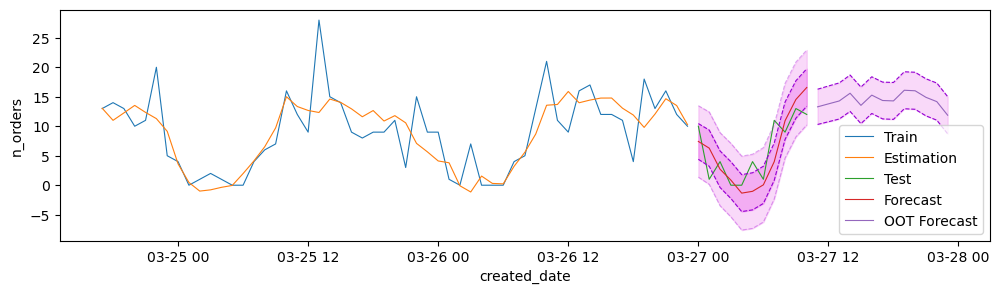

Processing account_id: ca35e88d-d191-4722-b90c-92f4a249869b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 33ms/step - loss: 849.7173 - val_loss: 643.1458
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 849.0324 - val_loss: 642.2474
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 847.2631 - val_loss: 639.9629
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 843.4528 - val_loss: 635.4534
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 837.2607 - val_loss: 628.4005
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 828.7247 - val_loss: 618.9554
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 819.3141 - val_loss: 607.6209
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 808.2545 - val_loss: 594.8359
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 797.6650 - val_loss: 581.1481
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 786.2620 - val_loss: 567.2985
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.033638
1,gb,0.613442
2,lstm,0.557318


train RMSE: 722.715
train MAE:  447.890
test RMSE: 438.539
test MAE:  273.466


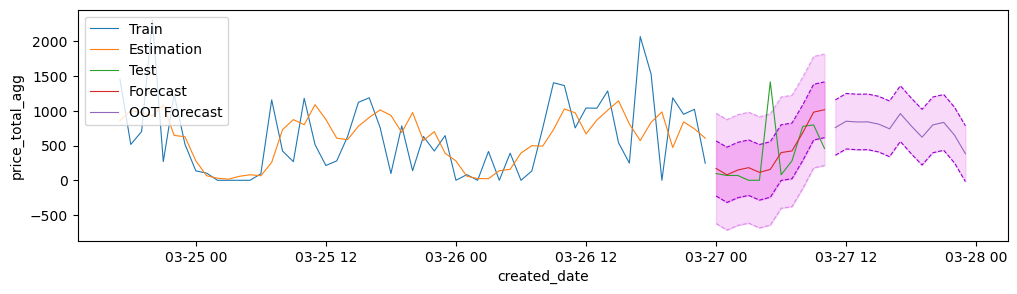

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 4.1068 - val_loss: 2.8624
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 3.4996 - val_loss: 2.2905
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 2.8843 - val_loss: 1.9506
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 2.5186 - val_loss: 1.8356
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 2.4068 - val_loss: 1.7821
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 2.3461 - val_loss: 1.7603
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 2.3066 - val_loss: 1.7217
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 2.2400 - val_loss: 1.7203
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 2.1968 - val_loss: 1.6943
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 2.1757 - val_loss: 1.6934
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 2.1487 - val_loss: 1.6779
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 2.1107 - val_loss: 1.6665
Epoch 13/1000
60

,feature,coef
0,tbats,-0.109824
1,gb,0.430515
2,lstm,0.889236


train RMSE: 2.836
train MAE:  1.803
test RMSE: 1.853
test MAE:  1.375


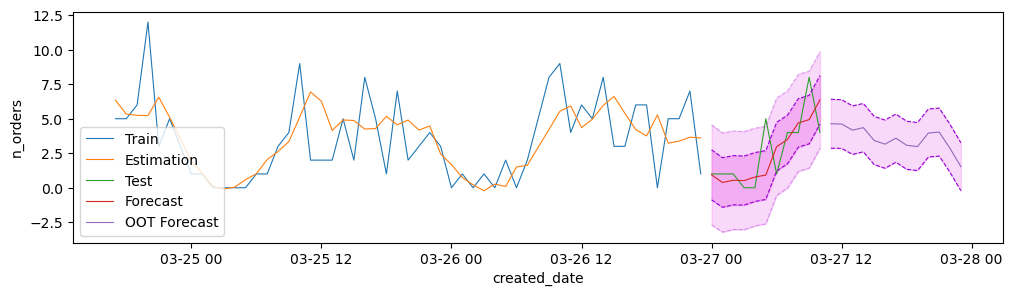

Processing account_id: aabe992c-cfad-4049-b5df-36c41f900a67, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 82.2447 - val_loss: 130.6293
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 82.2298 - val_loss: 130.6291
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 82.2201 - val_loss: 130.6203
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 82.2046 - val_loss: 130.6160
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 82.1928 - val_loss: 130.6058
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 82.1661 - val_loss: 130.5886
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 82.1318 - val_loss: 130.5601
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 82.1029 - val_loss: 130.5254
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 82.0320 - val_loss: 130.4721
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 81.9476 - val_loss: 130.4267
Epoch 11/1000
60/60 - 0s - 1ms/step 

,feature,coef
0,tbats,0.702639
1,gb,0.000000
2,lstm,1.020760


train RMSE: 216.206
train MAE:  110.588
test RMSE: 89.550
test MAE:  79.016


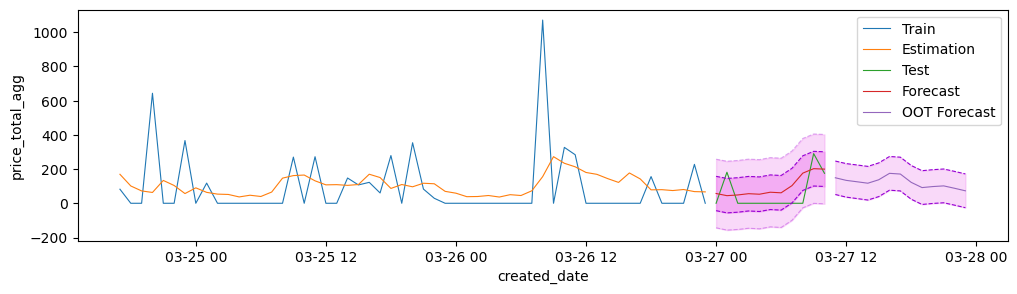

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 0.4184 - val_loss: 0.4868
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.4058 - val_loss: 0.4847
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.4004 - val_loss: 0.4822
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.3937 - val_loss: 0.4805
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 0.3899 - val_loss: 0.4807
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 0.3888 - val_loss: 0.4786
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 0.3849 - val_loss: 0.4795
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 0.3843 - val_loss: 0.4815
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 0.3828 - val_loss: 0.4785
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 0.3831 - val_loss: 0.4788
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 0.3778 - val_loss: 0.4786
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 0.3792 - val_loss: 0.4771
Epoch 13/1000
60

,feature,coef
0,tbats,0.672685
1,gb,0.000000
2,lstm,0.546523


train RMSE: 0.661
train MAE:  0.466
test RMSE: 0.368
test MAE:  0.268


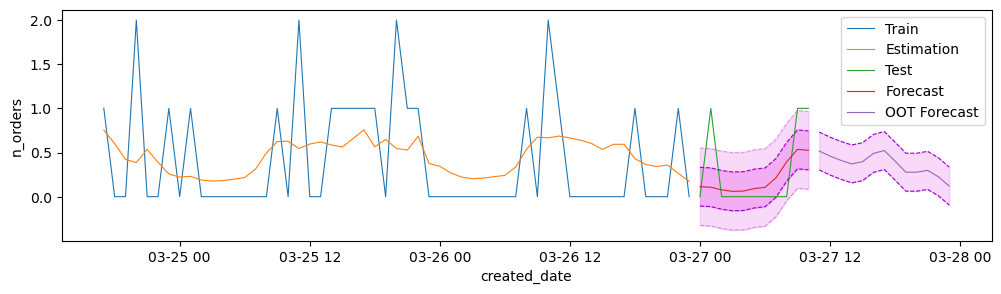

Processing account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 14ms/step - loss: 970.0976 - val_loss: 703.3393
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 969.6572 - val_loss: 703.2903
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 968.6564 - val_loss: 703.2417
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 966.5224 - val_loss: 703.2366
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 962.8936 - val_loss: 703.3569
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 957.9594 - val_loss: 703.6691
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 950.8049 - val_loss: 704.1740
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 970.2427 - val_loss: 653.1273
Epoch 2/1000
61/61 - 0s - 4ms/step - loss: 969.7749 - val_loss: 653.1298
Epoch 3/1000
61/61 - 0

,feature,coef
0,tbats,0.904376
1,gb,1.168747
2,lstm,-4.611389


train RMSE: 2627.121
train MAE:  768.815
test RMSE: 438.697
test MAE:  395.152


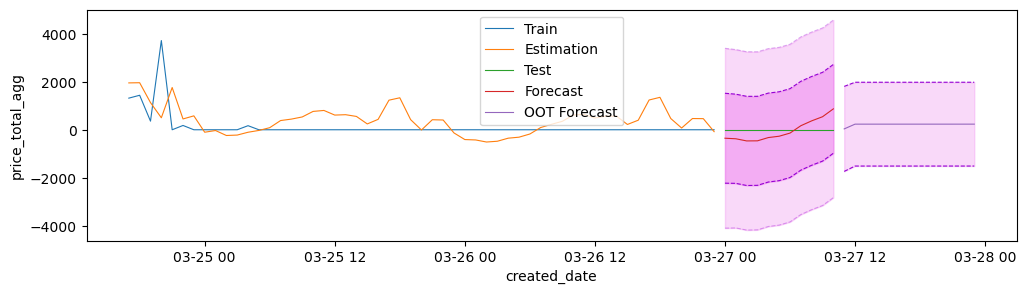

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 2.2747 - val_loss: 1.6630
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.8692 - val_loss: 1.6413
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.5849 - val_loss: 1.7508
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.5170 - val_loss: 1.7503
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.4935 - val_loss: 1.7271
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Epoch 1/1000
61/61 - 1s - 11ms/step - loss: 2.2061 - val_loss: 1.5851
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 1.7827 - val_loss: 1.7090
Epoch 3/1000
61/61 - 0s - 3ms/step - loss: 1.5629 - val_loss: 1.8083
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 1.5145 - val_loss: 1.7998
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

,feature,coef
0,tbats,0.644177
1,gb,0.684640
2,lstm,-0.160423


train RMSE: 3.265
train MAE:  1.297
test RMSE: 1.106
test MAE:  1.010


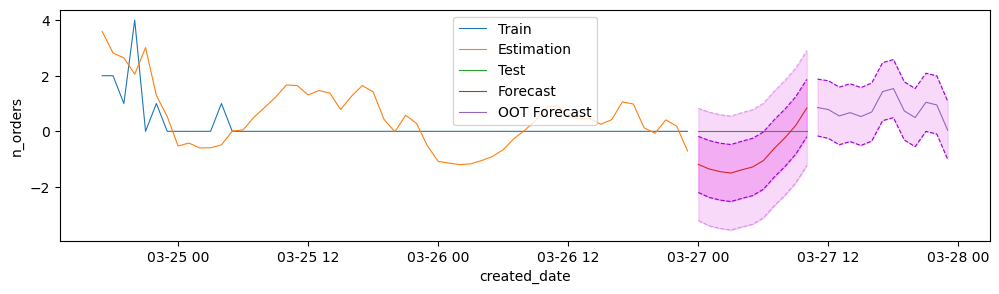

Processing account_id: 22fde42e-45d7-46cd-9d6f-3a4dbabbc579, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 261.6621 - val_loss: 251.4812
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 261.4982 - val_loss: 251.2706
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 261.1610 - val_loss: 250.7460
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 260.3385 - val_loss: 249.6239
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 258.8301 - val_loss: 247.6805
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 256.5727 - val_loss: 244.8820
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 253.7348 - val_loss: 241.7072
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 250.6915 - val_loss: 238.3591
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 247.6900 - val_loss: 234.8314
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 245.0970 - val_loss: 231.6258
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.493495
1,gb,0.695729
2,lstm,0.667640


train RMSE: 525.340
train MAE:  258.815
test RMSE: 189.400
test MAE:  105.226


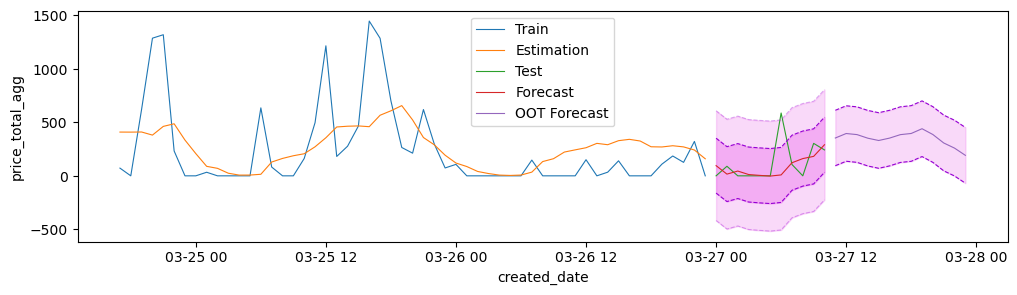

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 1.6374 - val_loss: 1.2191
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.5369 - val_loss: 1.1049
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.4226 - val_loss: 0.9761
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.3747 - val_loss: 0.9476
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.3548 - val_loss: 0.9398
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 1.3300 - val_loss: 0.9335
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 1.3298 - val_loss: 0.9284
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.3206 - val_loss: 0.9265
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 1.3063 - val_loss: 0.9188
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 1.2942 - val_loss: 0.9153
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 1.2842 - val_loss: 0.9149
Epoch 12/1000
60/60 - 0s - 1ms/step - loss: 1.2795 - val_loss: 0.9158
Epoch 13/1000
60

,feature,coef
0,tbats,0.030818
1,gb,0.173760
2,lstm,1.526212


train RMSE: 3.158
train MAE:  1.286
test RMSE: 1.004
test MAE:  0.715


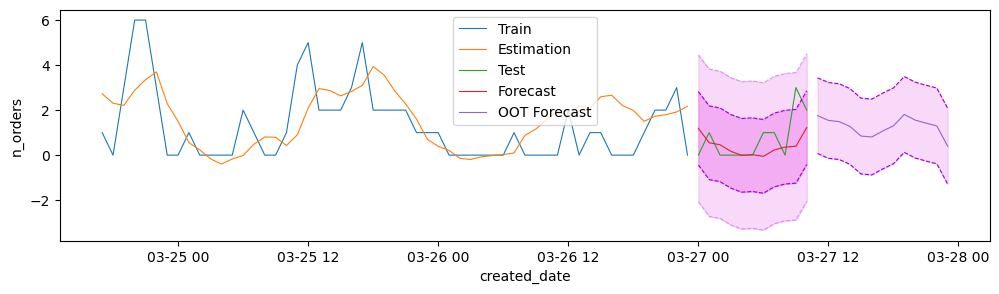

Processing account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━

,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


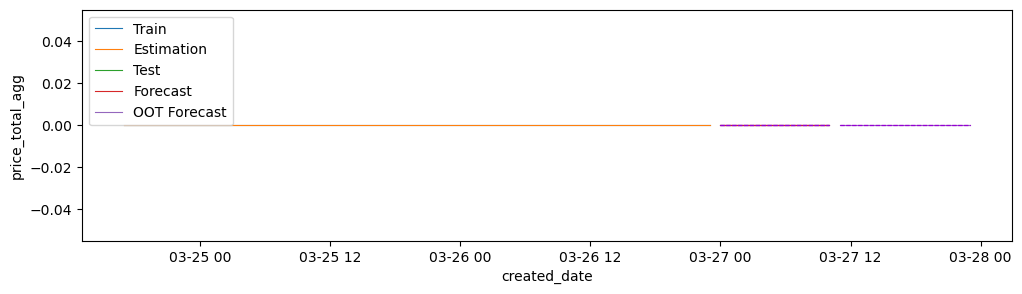

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 3s - 50ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Epoch 1/1000
61/61 - 1s - 16ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


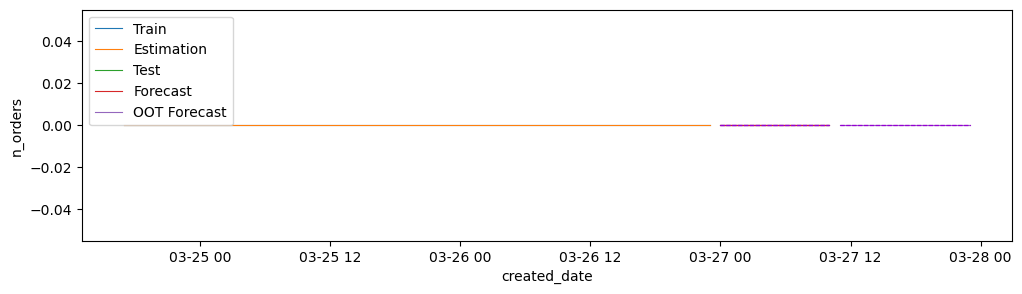

Processing account_id: 50409b57-b000-43d5-9358-44c3081c4132, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 284.4060 - val_loss: 467.9049
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 284.3316 - val_loss: 467.6107
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 284.1858 - val_loss: 467.0091
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 283.9197 - val_loss: 465.9339
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 283.4722 - val_loss: 464.2436
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 282.8477 - val_loss: 461.8957
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 282.0344 - val_loss: 458.9302
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 280.9872 - val_loss: 455.3409
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 279.7050 - val_loss: 451.1626
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 278.3550 - val_loss: 446.5368
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.383939
1,gb,0.209740
2,lstm,0.851514


train RMSE: 560.710
train MAE:  291.962
test RMSE: 208.184
test MAE:  201.042


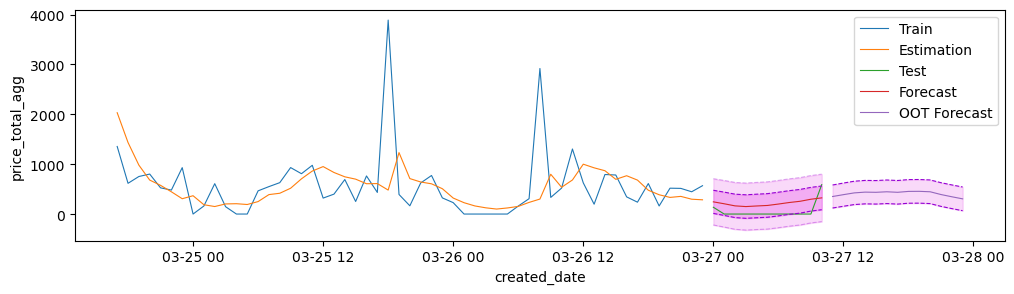

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 18ms/step - loss: 1.1756 - val_loss: 1.6725
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1.1162 - val_loss: 1.5139
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.0432 - val_loss: 1.3731
Epoch 4/1000
60/60 - 0s - 5ms/step - loss: 0.9767 - val_loss: 1.3113
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 0.9404 - val_loss: 1.2607
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 0.9474 - val_loss: 1.2447
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 0.9191 - val_loss: 1.2241
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 0.9145 - val_loss: 1.1968
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 0.9333 - val_loss: 1.2126
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 0.9196 - val_loss: 1.1890
Epoch 11/1000
60/60 - 0s - 1ms/step - loss: 0.9216 - val_loss: 1.1652
Epoch 12/1000
60/60 - 0s - 2ms/step - loss: 0.9149 - val_loss: 1.1545
Epoch 13/1000
60

,feature,coef
0,tbats,-0.097694
1,gb,0.870244
2,lstm,0.542121


train RMSE: 1.564
train MAE:  0.900
test RMSE: 0.847
test MAE:  0.392


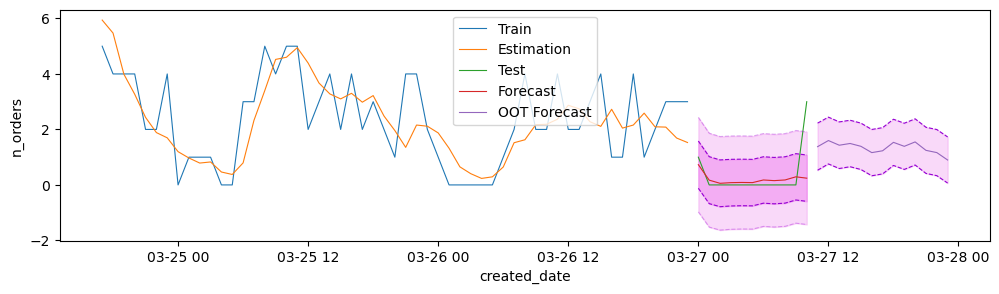

Processing account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 144.2399 - val_loss: 88.7695
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 144.1611 - val_loss: 88.7641
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 144.0016 - val_loss: 88.7381
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 143.6244 - val_loss: 88.6698
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 142.9697 - val_loss: 88.5376
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 141.7988 - val_loss: 88.3084
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 140.3573 - val_loss: 88.0082
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 138.5932 - val_loss: 87.6682
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 136.8020 - val_loss: 87.3253
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 135.3974 - val_loss: 87.0392
Epoch 11/1000
60/60 - 0s - 1ms/step 

,feature,coef
0,tbats,0.910415
1,gb,0.000000
2,lstm,0.160577


train RMSE: 189.413
train MAE:  133.978
test RMSE: 71.177
test MAE:  52.127


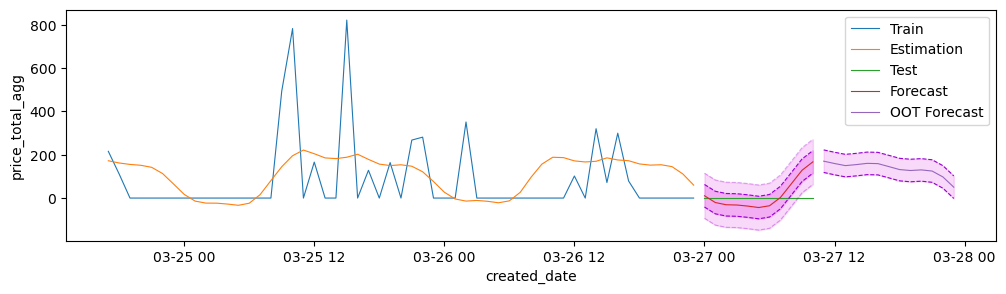

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 10ms/step - loss: 0.6845 - val_loss: 0.4585
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 0.6231 - val_loss: 0.4597
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 0.6092 - val_loss: 0.4592
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 0.6048 - val_loss: 0.4586
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/1000
61/61 - 1s - 9ms/step - loss: 0.6866 - val_loss: 0.4431
Epoch 2/1000
61/61 - 0s - 1ms/step - loss: 0.6344 - val_loss: 0.4396
Epoch 3/1000
61/61 - 0s - 1ms/step - loss: 0.6103 - val_loss: 0.4438
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 0.6016 - val_loss: 0.4425
Epoch 5/1000
61/61 - 0s - 1ms/step - loss: 0.5994 - val_loss: 0.4431
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10

,feature,coef
0,tbats,0.710758
1,gb,0.000000
2,lstm,0.397885


train RMSE: 0.823
train MAE:  0.578
test RMSE: 0.292
test MAE:  0.220


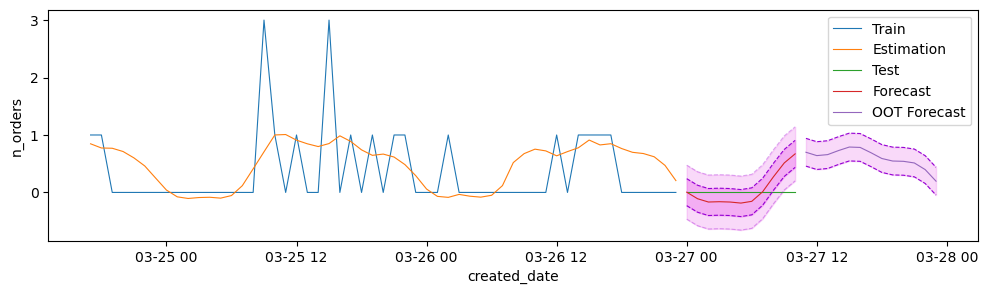

Processing account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 369.3732 - val_loss: 626.3547
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 368.7382 - val_loss: 625.2510
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 366.6538 - val_loss: 622.0524
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 362.2497 - val_loss: 616.0845
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 355.2100 - val_loss: 607.7674
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 347.0091 - val_loss: 598.0782
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 337.6926 - val_loss: 588.2208
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 329.7907 - val_loss: 579.9888
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 322.0838 - val_loss: 573.2626
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 317.5569 - val_loss: 567.4310
Epoch 11/1000
60/60 - 0s -

,feature,coef
0,tbats,0.821161
1,gb,0.173785
2,lstm,-0.004587


train RMSE: 1279.742
train MAE:  348.831
test RMSE: 1594.626
test MAE:  1550.098


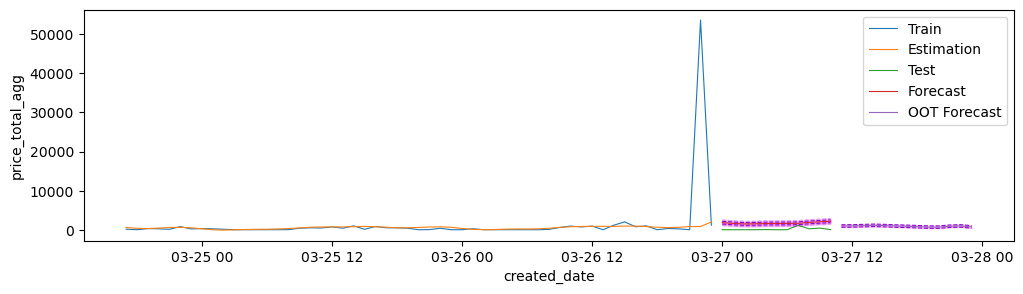

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 9ms/step - loss: 1.3516 - val_loss: 1.2299
Epoch 2/1000
60/60 - 0s - 1ms/step - loss: 1.0659 - val_loss: 1.1691
Epoch 3/1000
60/60 - 0s - 1ms/step - loss: 1.0324 - val_loss: 1.1763
Epoch 4/1000
60/60 - 0s - 1ms/step - loss: 1.0203 - val_loss: 1.1619
Epoch 5/1000
60/60 - 0s - 1ms/step - loss: 1.0311 - val_loss: 1.1607
Epoch 6/1000
60/60 - 0s - 1ms/step - loss: 1.0076 - val_loss: 1.1584
Epoch 7/1000
60/60 - 0s - 1ms/step - loss: 1.0133 - val_loss: 1.1553
Epoch 8/1000
60/60 - 0s - 1ms/step - loss: 1.0025 - val_loss: 1.1575
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 1.0001 - val_loss: 1.1592
Epoch 10/1000
60/60 - 0s - 1ms/step - loss: 0.9962 - val_loss: 1.1566
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 1.3904 - val_loss: 1.2900
Epoch 2/

,feature,coef
0,tbats,0.684781
1,gb,0.187564
2,lstm,0.152765


train RMSE: 1.423
train MAE:  0.981
test RMSE: 1.392
test MAE:  1.127


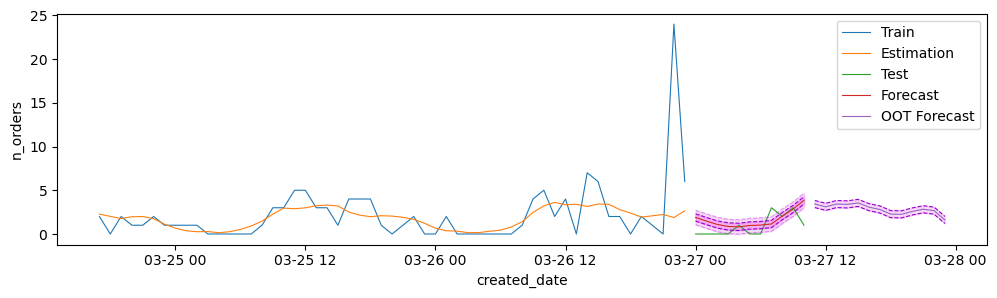

Processing account_id: 478cd985-f4fc-45b4-ac71-bf78cf11e07b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 1007.8476 - val_loss: 561.7053
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 1006.5020 - val_loss: 560.7521
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 1002.3563 - val_loss: 558.2641
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 994.0714 - val_loss: 553.7303
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 980.8657 - val_loss: 546.8704
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 962.8860 - val_loss: 538.0193
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 941.7285 - val_loss: 527.5858
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 917.5939 - val_loss: 515.9330
Epoch 9/1000
60/60 - 0s - 1ms/step - loss: 889.1549 - val_loss: 502.8478
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 860.4841 - val_loss: 489.1259
Epoch 11/1000
60/60 - 0

,feature,coef
0,tbats,0.525986
1,gb,0.597770
2,lstm,-0.056848


train RMSE: 648.158
train MAE:  449.757
test RMSE: 232.626
test MAE:  206.646


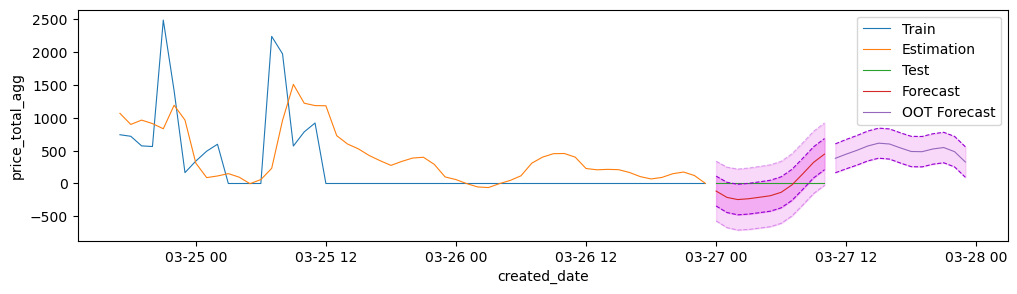

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 15ms/step - loss: 4.7013 - val_loss: 2.0889
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 3.8927 - val_loss: 1.7726
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 2.8065 - val_loss: 1.5743
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 2.4744 - val_loss: 1.5224
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 2.3643 - val_loss: 1.4875
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 2.3480 - val_loss: 1.4562
Epoch 7/1000
60/60 - 0s - 2ms/step - loss: 2.2676 - val_loss: 1.4399
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 2.2369 - val_loss: 1.4316
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 2.1978 - val_loss: 1.4211
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 2.2375 - val_loss: 1.4272
Epoch 11/1000
60/60 - 0s - 2ms/step - loss: 2.1722 - val_loss: 1.4122
Epoch 12/1000
60/60 - 0s - 3ms/step - loss: 2.1509 - val_loss: 1.3956
Epoch 13/1000
60

,feature,coef
0,tbats,0.432537
1,gb,0.210171
2,lstm,0.429672


train RMSE: 2.893
train MAE:  1.905
test RMSE: 1.280
test MAE:  1.114


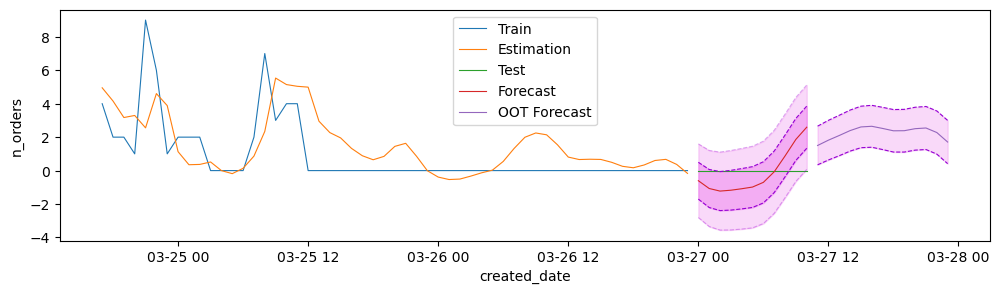

Processing account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 12ms/step - loss: 870.1882 - val_loss: 1050.9626
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 866.0476 - val_loss: 1042.2205
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 853.4397 - val_loss: 1022.9760
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 831.7652 - val_loss: 994.7969
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 802.7293 - val_loss: 959.8610
Epoch 6/1000
60/60 - 0s - 2ms/step - loss: 766.9980 - val_loss: 918.0552
Epoch 7/1000
60/60 - 0s - 3ms/step - loss: 725.6574 - val_loss: 870.3199
Epoch 8/1000
60/60 - 0s - 2ms/step - loss: 679.2976 - val_loss: 817.6849
Epoch 9/1000
60/60 - 0s - 2ms/step - loss: 629.0132 - val_loss: 761.6645
Epoch 10/1000
60/60 - 0s - 2ms/step - loss: 580.9181 - val_loss: 708.1256
Epoch 11/1000
60/60 - 0

,feature,coef
0,tbats,0.647775
1,gb,0.498626
2,lstm,-0.087399


train RMSE: 527.250
train MAE:  362.111
test RMSE: 463.544
test MAE:  347.380


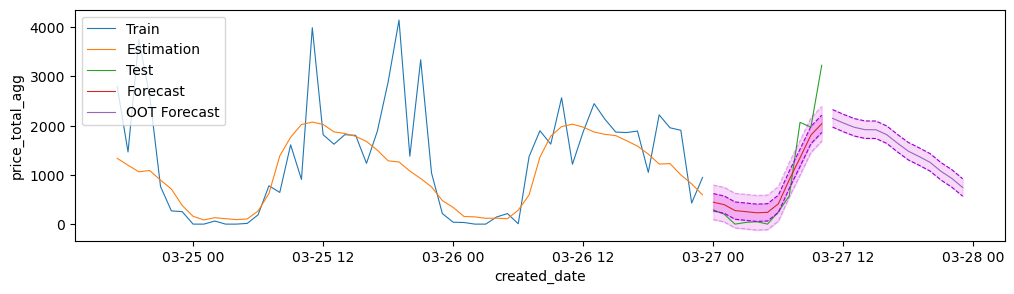

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 2s - 34ms/step - loss: 6.3183 - val_loss: 5.3581
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 3.4973 - val_loss: 2.5081
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 2.6657 - val_loss: 2.5487
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 2.6704 - val_loss: 2.5362
Epoch 5/1000
60/60 - 0s - 2ms/step - loss: 2.6021 - val_loss: 2.5297
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 1/1000
61/61 - 1s - 10ms/step - loss: 6.4837 - val_loss: 5.6234
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 3.8010 - val_loss: 2.6135
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 2.7148 - val_loss: 2.5682
Epoch 4/1000
61/61 - 0s - 1ms/step - loss: 2.6773 - val_loss: 2.5325
Epoch 5/1000
61/61 - 0s - 2ms/step - loss: 2.6256 - val_loss: 2.5622
Epoch 6/1000
61/61 - 0s - 2ms/step - loss: 2.5860 - val_loss: 2.5345
Epoch 7/10

,feature,coef
0,tbats,0.464917
1,gb,0.869820
2,lstm,-0.282530


train RMSE: 2.763
train MAE:  1.961
test RMSE: 1.381
test MAE:  1.007


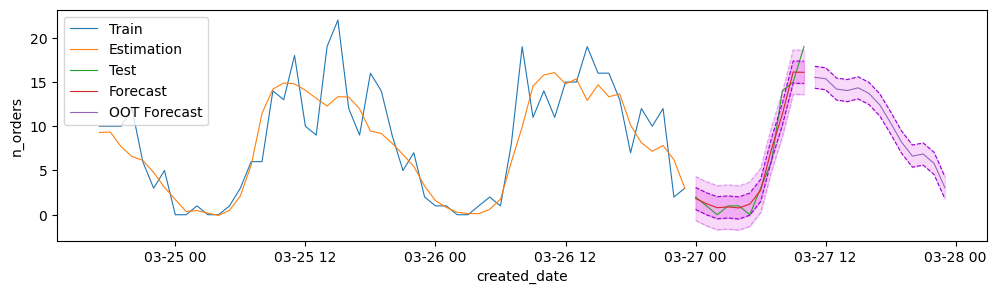

In [9]:
def preprocess_sales_data(account_id, sales_channel_id):
    if sales_channel_id == 'ALL':
        cond = (sales['account_id'] == account_id) & \
               (sales['status'].notna())
    else:
        cond = (sales['account_id'] == account_id) & \
               (sales['sales_channel_id'] == sales_channel_id) & \
               (sales['status'].notna())
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(
        price_total_agg=('price_total', 'sum'),
        n_orders=('created_date', 'count')
    )
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    return df_client_mod


def create_lagged_features(df, lags=24):
    lagged_features = [df.shift(l).rename(f'lag_{l}') for l in range(1, lags + 1)]
    df_lag = pd.concat([df, pd.concat(lagged_features, axis=1)], axis=1).dropna().asfreq('h')
    return df_lag


def split_data(df_lag):
    df_train = df_lag.loc[df_lag.index < START_DATE].copy()
    df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
    df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
    return df_train, df_test, df_oot


def train_and_forecast_tbats(df_train, df_test, df_full, df_oot, col, SEASONAL_PERIODS):
    model = TBATS(sp=SEASONAL_PERIODS, show_warnings=False, n_jobs=-1)
    model.fit(df_train[col])
    
    estimations = model.predict(fh=df_train.index)

    forecast = model.predict(fh=df_test.index)
    forecast_int = model.predict_interval(fh=df_test.index, coverage=COVERAGE)
    forecast_lower, forecast_upper = forecast_int.iloc[:, 0], forecast_int.iloc[:, 1]

    oot_model = TBATS(sp=SEASONAL_PERIODS, show_warnings=False, n_jobs=-1)
    oot_model.fit(df_full[col])
    
    oot_estimations = oot_model.predict(fh=df_full.index)

    oot_forecast = oot_model.predict(fh=df_oot.index)
    oot_forecast_int = oot_model.predict_interval(fh=df_oot.index, coverage=COVERAGE)
    oot_forecast_lower, oot_forecast_upper = oot_forecast_int.iloc[:, 0], oot_forecast_int.iloc[:, 1]
    
    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_estimations': oot_estimations,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }


def train_and_forecast_gb(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    X_full, y_full = df_full.drop(col, axis=1), df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    train_mad = y_train.std()
    mad = y_full.std()
    
    gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                        param_grid={'max_depth': [1, 2, 4, 8, 16],
                                    'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                    'max_features': ['sqrt', 'log2', None]},
                        scoring='neg_mean_absolute_error',
                        cv=TimeSeriesSplit(),
                        n_jobs=-1,
                        verbose=1)
    gscv.fit(X_train, y_train)
    model = gscv.best_estimator_
    
    estimations = pd.Series(model.predict(X_train), index=X_train.index)

    forecast = pd.Series(model.predict(X_test), index=X_test.index)
    forecast_lower = forecast - CRIT_VALUE*train_mad
    forecast_upper = forecast + CRIT_VALUE*train_mad

    oot_gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                            param_grid={'max_depth': [1, 2, 4, 8, 16],
                                        'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                        'max_features': ['sqrt', 'log2', None]},
                            scoring='neg_mean_absolute_error',
                            cv=TimeSeriesSplit(),
                            n_jobs=-1,
                            verbose=1)
    oot_gscv.fit(X_full, y_full)
    oot_model = gscv.best_estimator_
    
    oot_estimations = pd.Series(oot_model.predict(X_full), index=X_full.index)
    
    oot_forecast_ls = []
    oot_forecast_lower_ls = []
    oot_forecast_upper_ls = []
    for i in range(len(X_oot)):
        x_oot = X_oot.iloc[i].to_frame().T
        
        x_oot_forecast = oot_model.predict(x_oot)[0]
        oot_forecast_ls.append(x_oot_forecast)
        oot_forecast_lower_ls.append(x_oot_forecast - CRIT_VALUE*mad)
        oot_forecast_upper_ls.append(x_oot_forecast + CRIT_VALUE*mad)
        
        for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
            X_oot.iloc[j, k] = x_oot_forecast
            
    oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index)
    oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_estimations': oot_estimations,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }


def train_and_forecast_lstm(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    X_full, y_full = df_full.drop(col, axis=1), df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    train_mad = y_train.std()
    mad = y_full.std()
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    X_train_scaled = np.reshape(X_train_scaled, (X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = np.reshape(X_test_scaled, (X_test.shape[0], 1, X_test.shape[1]))
    
    early_stopping = EarlyStopping(patience=3)
    model = Sequential()
    model.add(Input(shape=(1, 24)))
    model.add(LSTM(128, activation='relu', return_sequences=True))
    model.add(Dropout(0.5))
    model.add(Dense(1))
    model.compile(loss='mean_absolute_error', optimizer='adam')
    model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    estimations = pd.Series(model.predict(X_train_scaled).squeeze(), index=X_train.index)

    forecast = pd.Series(model.predict(X_test_scaled).squeeze(), index=X_test.index)
    forecast_lower = forecast - CRIT_VALUE*train_mad
    forecast_upper = forecast + CRIT_VALUE*train_mad
    
    scaler = StandardScaler()
    X_full_scaled = np.reshape(scaler.fit_transform(X_full), (X_full.shape[0], 1, X_full.shape[1]))

    early_stopping = EarlyStopping(patience=3)
    oot_model = Sequential()
    oot_model.add(Input(shape=(1, 24)))
    oot_model.add(LSTM(128, activation='relu', return_sequences=True))
    oot_model.add(Dropout(0.5))
    oot_model.add(Dense(1))
    oot_model.compile(loss='mean_absolute_error', optimizer='adam')
    oot_model.fit(X_full_scaled, y_full, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
    
    oot_estimations = pd.Series(oot_model.predict(X_full_scaled).squeeze(), index=X_full.index)
    
    oot_forecast_ls = []
    oot_forecast_lower_ls = []
    oot_forecast_upper_ls = []
    for i in range(len(X_oot)):
        x_oot = X_oot.iloc[i].to_frame().T
        x_oot_scaled = scaler.transform(x_oot)
        x_oot_scaled = np.reshape(x_oot_scaled, (x_oot.shape[0], 1, x_oot.shape[1]))
        
        x_oot_forecast = oot_model.predict(x_oot_scaled).squeeze()
        oot_forecast_ls.append(x_oot_forecast)
        oot_forecast_lower_ls.append(x_oot_forecast - CRIT_VALUE*mad)
        oot_forecast_upper_ls.append(x_oot_forecast + CRIT_VALUE*mad)
        
        for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
            X_oot.iloc[j, k] = x_oot_forecast
            
    oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index).astype(float)
    oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_estimations': oot_estimations,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }


def train_and_forecast_ens(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    y_full = df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    tbats_results = train_and_forecast_tbats(df_train, df_test, df_full, df_oot, col, SEASONAL_PERIODS)
    gb_results = train_and_forecast_gb(df_train, df_test, df_full, df_oot, col)
    lstm_results = train_and_forecast_lstm(df_train, df_test, df_full, df_oot, col)
    
    models_estimations = pd.concat([tbats_results['estimations'],
                                    gb_results['estimations'],
                                    lstm_results['estimations']], axis=1)
    models_estimations.columns = ['tbats', 'gb', 'lstm']
    model = LinearRegression()
    model.fit(models_estimations, y_train)
    estimations = pd.Series(model.predict(models_estimations), index=X_train.index)
    
    models_forecast = pd.concat([tbats_results['forecast'],
                                 gb_results['forecast'],
                                 lstm_results['forecast']], axis=1)
    models_forecast.columns = ['tbats', 'gb', 'lstm']
    
    models_forecast_lower = pd.concat([tbats_results['forecast_lower'],
                                       gb_results['forecast_lower'],
                                       lstm_results['forecast_lower']], axis=1)
    models_forecast_lower.columns = ['tbats', 'gb', 'lstm']
    
    models_forecast_upper = pd.concat([tbats_results['forecast_upper'],
                                       gb_results['forecast_upper'],
                                       lstm_results['forecast_upper']], axis=1)
    models_forecast_upper.columns = ['tbats', 'gb', 'lstm']
    
    forecast = pd.Series(model.predict(models_forecast), index=X_test.index)
    forecast_lower = pd.Series(model.predict(models_forecast_lower), index=X_test.index)
    forecast_upper = pd.Series(model.predict(models_forecast_upper), index=X_test.index)
    
    oot_estimations = pd.concat([tbats_results['oot_estimations'],
                                 gb_results['oot_estimations'],
                                 lstm_results['oot_estimations']], axis=1)
    oot_estimations.columns = ['tbats', 'gb', 'lstm']
    oot_model = LinearRegression()
    oot_model.fit(oot_estimations, y_full)
    
    display(pd.DataFrame(zip(oot_model.feature_names_in_, oot_model.coef_), columns=['feature', 'coef']))
    
    oot_models_forecast = pd.concat([tbats_results['oot_forecast'],
                                     gb_results['oot_forecast'],
                                     lstm_results['oot_forecast']], axis=1)
    oot_models_forecast.columns = ['tbats', 'gb', 'lstm']
    
    oot_models_forecast_lower = pd.concat([tbats_results['oot_forecast_lower'],
                                           gb_results['oot_forecast_lower'],
                                           lstm_results['oot_forecast_lower']], axis=1)
    oot_models_forecast_lower.columns = ['tbats', 'gb', 'lstm']
    
    oot_models_forecast_upper = pd.concat([tbats_results['oot_forecast_upper'],
                                           gb_results['oot_forecast_upper'],
                                           lstm_results['oot_forecast_upper']], axis=1)
    oot_models_forecast_upper.columns = ['tbats', 'gb', 'lstm']
    
    oot_forecast = pd.Series(oot_model.predict(oot_models_forecast), index=X_oot.index)
    oot_forecast_lower = pd.Series(oot_model.predict(oot_models_forecast_lower), index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_model.predict(oot_models_forecast_upper), index=X_oot.index)
    
    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }
    
    
def compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col):
    y_train = df_train[col]
    y_test = df_test[col]
    estimations = forecast_results['estimations']
    forecast = forecast_results['forecast']
    forecast_lower = forecast_results['forecast_lower']
    forecast_upper = forecast_results['forecast_upper']
    oot_forecast = forecast_results['oot_forecast']
    oot_forecast_lower = forecast_results['oot_forecast_lower']
    oot_forecast_upper = forecast_results['oot_forecast_upper']
    
    train_mae = mean_absolute_error(df_train[col], estimations)
    train_rmse = root_mean_squared_error(df_train[col], estimations)
    print(f"train RMSE: {train_rmse:.3f}")
    print(f"train MAE:  {train_mae:.3f}")
    test_mae = mean_absolute_error(df_test[col], forecast)
    test_rmse = root_mean_squared_error(df_test[col], forecast)
    print(f"test RMSE: {test_rmse:.3f}")
    print(f"test MAE:  {test_mae:.3f}")
    
    plt.figure(figsize=(12, 3))
    sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
    sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
    sns.lineplot(y_test, lw=0.8, label='Test')
    sns.lineplot(forecast, lw=0.8, label='Forecast')
    sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
    sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    plt.fill_between(x=forecast.index,
                     y1=forecast_lower,
                     y2=forecast_upper,
                     color='violet',
                     alpha=0.5)
    plt.fill_between(x=forecast.index,
                     y1=2*forecast_lower-forecast,
                     y2=2*forecast_upper-forecast,
                     color='violet',
                     alpha=0.3)
    plt.fill_between(x=oot_forecast.index,
                     y1=oot_forecast_lower,
                     y2=oot_forecast_upper,
                     color='violet',
                     alpha=0.3)
    plt.legend()
    plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_ens.png')
    plt.show()
    
    return train_rmse, test_rmse, train_mae, test_mae


def save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict):
    with open(f'sql/time_series/forecast_{account_id}_{sales_channel_id}_ts.sql', 'w') as output_file:
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['forecast'].iloc[i]});
                """
            )
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast'].iloc[i]});
                """
            )


# Main
if ALL_SALES_CHANNELS:
    id_pairs = set(list(zip(df_count['account_id'], ['ALL']*len(df_count))))
else:
    id_pairs = list(zip(df_count['account_id'], df_count['sales_channel_id']))

summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'Processing account_id: {account_id}, sales_channel_id: {sales_channel_id}')
    summary_dict[(account_id, sales_channel_id)] = {}

    df_client_mod = preprocess_sales_data(account_id, sales_channel_id)
    df_client_mod.fillna(0, inplace=True)

    forecast_dict = {}
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(f'Processing column: {col}')
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {'name': col}

        df_lag = create_lagged_features(df_client_mod[col])
        df_train, df_test, df_oot = split_data(df_lag)
        df_full = pd.concat([df_train, df_test], axis=0)

        forecast_results = train_and_forecast_ens(df_train, df_test, df_full, df_oot, col)
        
        forecast_dict[f'dataset_{n}'] = {}
        forecast_dict[f'dataset_{n}'].update(forecast_results)
        
        train_rmse, test_rmse, train_mae, test_mae = compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col)
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae

    save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict)

In [10]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [11]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ml.csv', sep=';')

summary

,account_id,sales_channel_id,dataset,train RMSE,test RMSE,train MAE,test MAE
0,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,price_total_agg,11648.391821,4425.38875,6918.353225,3189.242012
1,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,n_orders,29.691911,11.160828,15.946984,6.60345
2,0661e926-f219-456e-bde5-612fee6f891c,ALL,price_total_agg,864.089246,388.189697,375.735354,285.94842
3,0661e926-f219-456e-bde5-612fee6f891c,ALL,n_orders,5.099264,1.494521,1.783614,1.218708
4,0ad2f65b-ee0e-4d50-93e2-84b76282325f,ALL,price_total_agg,4185.582151,1753.470351,2814.700619,1547.993775
...,...,...,...,...,...,...,...
69,e2de40dd-743b-4105-9077-3f343fea980d,ALL,n_orders,4.951891,2.497076,3.236007,2.109974
70,f4471620-212b-4991-98d3-b498835d0c29,ALL,price_total_agg,0.0,0.0,0.0,0.0
71,f4471620-212b-4991-98d3-b498835d0c29,ALL,n_orders,0.0,0.0,0.0,0.0
72,f9129295-bb08-4330-b60c-9f0beadda521,ALL,price_total_agg,74680.302307,36062.51932,34524.5313,30555.479088


In [12]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

dataset
n_orders              3.927147
price_total_agg    1758.374699
Name: train MAE, dtype: object

In [13]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

dataset
n_orders             19.511746
price_total_agg    1972.552172
Name: test MAE, dtype: object

In [14]:
(train_metrics - test_metrics).abs()

dataset
n_orders            15.584599
price_total_agg    214.177473
dtype: object